## Optional frontier-model experiments (not part of the stable baseline)

The uploaded notebooks contain additional DINOv3, RadImageNet, and CoAtNet inference branches.
They are intentionally **not included in the baseline training path**.

Use them only after the baseline has:
- a valid OOF protocol,
- reproducible fold scores,
- stable preprocessing,
- validated submissions, and
- an ablation showing that the added branch improves OOF performance rather than only a public score.


In [1]:
import torch

print("PyTorch :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("CUDA version :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU count :", torch.cuda.device_count())
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("CUDA KHÔNG khả dụng")

PyTorch : 2.10.0+cu128
CUDA available : True
CUDA version : 12.8
GPU count : 2
GPU : Tesla T4


## 1. What the score rewards

The score is the unweighted mean of twelve per-label ROC AUCs:

$$\text{Score} \;=\; \frac{1}{12}\sum_{i=0}^{11} \mathrm{AUC}_i .$$

Three consequences follow directly, and each one removes a design choice.

**Only order matters.** $\mathrm{AUC}_i$ is invariant under any strictly increasing map
of the scores for label $i$. Calibration is therefore worth nothing, and a fixed
threshold is worth nothing. It also fixes how to combine models: averaging raw
probabilities lets whichever model happens to be most confident dominate, whereas
averaging *ranks* combines the only information the metric reads. Every combination
below is a rank mean.

**Every label costs the same.** Write $M$ for the mean AUC a good model could reach.
A label left at chance contributes $0.5$ instead of roughly $M$, so it forfeits

$$\frac{M - 0.5}{12}$$

of the final score no matter how well the other eleven do. At $M = 0.85$ that is
$0.029$ — larger than the gap between neighbouring places in a mature competition.
Rare findings deserve *more* attention than common ones, not less, because a rare
finding is where a model most easily ends up at chance.

**Prevalence drifts are survivable, thresholds are not.** AUC is, in expectation,
invariant to the positive rate. The competition states that prevalence is not guaranteed
to match across the training, public and final sets, which would be fatal for any
accuracy-like metric and for anything tuned to a threshold. It is not fatal here,
provided nothing in the pipeline depends on a cutoff. Nothing below does.


## 2. Where the targets come from

Only a small subset of the training studies carry the twelve per-condition labels. Every
training study carries the original radiology report, and the data description invites
deriving labels from it.

The decisive structural fact is in the schemas rather than in the prose: `train.csv` has
a `Report` column and `test.csv` does not. Text is available when fitting and absent when
predicting. That rules out a fusion model with a text branch — at inference it would have
nothing to read — and leaves three admissible uses of the reports:

1. turn them into training targets, then fit a pure imaging model;
2. use them as an auxiliary training signal, distilled into the image encoder and dropped
   at inference;
3. use them to weight studies by how confidently their labels could be read.

This notebook takes the first and the third. A multilingual rule extractor reads each
report clause by clause, deciding for each finding whether the clause asserts it, negates
it, or hedges it, and emits a score together with a confidence. The confidence becomes a
sample weight, so a study whose report says nothing about synovitis pulls on the
synovitis head far less than one that names it.

Two details matter more than the extractor's internals.

**Reports are graded, annotations are thresholded.** The reporting radiologist and the
annotator do not share a threshold. A report that says *small joint effusion* may sit
against a negative annotation, because the annotator marked only effusions they judged
significant. A rule of the form *term present $\Rightarrow$ positive* is therefore wrong
by construction. Grading the mention — trace, unqualified, marked — is right, and costs
nothing, because §1 established that only the order of the scores is read.

**Derived labels are not independent across studies.** A report shared verbatim by
several studies yields one target vector for all of them. That has to be respected when
splitting; §7 does.


### Reading a report in nine languages

The extractor is the first model in this pipeline, so it is built here rather than
attached as a file. It runs over a few megabytes of text in seconds, and keeping it in
line means the targets can never be a stale copy of what the current rules would produce.

**Script settles itself; language does not.** Greek and Cyrillic are decided by Unicode
alone. The Latin-script remainder is scored by stopword counts across the candidate
languages and the winner must beat the runner-up by a margin; what fails that test stays
`unknown` rather than being guessed. The tempting shortcut — a cascade of substring tests,
`'the '` for English, `'la '` for French — fails badly here, because `la` is as common in
Spanish as in French and whichever test runs first swallows both.

**Normalise, then segment, then scope.** Case, diacritics and separators are folded first,
which also repairs a codepoint problem: many Greek reports spell mu with the MICRO SIGN
U+00B5 rather than U+03BC, and NFKD maps one onto the other. Text is then split into
clauses, with a heading line attached to the value beneath it, because a report that reads
`Fractures :` and then `Aucune.` states one thing across two lines and any method that
splits them reads a negation as a positive.

**Assertion, negation, hedge.** Within a clause the extractor asks which of three things
the sentence is doing. Negation is not an edge case: for several findings most mentions
are negative, since a report lists what was checked and found intact. Explicit normality
counts as negation — *ligamentos cruzados y colaterales dentro de límites normales* is
evidence of absence, not absence of evidence — except where a tear or a high grade is
named in the same breath.

**Stems, not phrases.** Four targets need an anatomy word and a pathology word together,
and a lexicon of complete phrases cannot survive morphology: Turkish suffixes possessives
onto the noun, Croatian and Greek decline it. Matching a stem and then requiring a side
qualifier within a character window handles inflection without enumerating it, and a
character window rather than a token window handles word order, which puts the side
adjective before the noun in English and after it in Greek.

**Grade, do not threshold.** §1 established that only the order of the scores is read, and
§2 that the annotator's threshold is stricter than the reporting radiologist's. Together
those say a mention should be scored by its emphasis — trace, unqualified, marked — and
never binarised. Each target also carries a confidence, which becomes the sample weight:
silence on a finding is weak evidence, and it should pull on the model weakly.

### How an extractor like this is validated

This is the part that decides whether any of the above is worth trusting, and it is
harder than writing the rules, because the obvious measurement is the one that cannot
carry the weight.

**The dangerous failure is silent.** A rule that never fires does not raise an error; it
emits a negative. A lexicon that is complete in English and thin in Greek therefore does
not look broken — it looks like a corpus where Greek patients have fewer findings. Worse,
the error is not random: language tracks the reporting institution, which tracks the
scanner and the population, so a gap in one language is a systematic bias aligned with a
site rather than noise that averages out.

**Gauge one: agreement, on the annotated subset.** For each target, compare the extracted
score against the per-condition annotation and read the AUC. This measures the right
thing, and it is nearly useless for tuning, because that subset is small. The
Hanley–McNeil approximation for the standard error of an AUC $A$ with $n_p$ positives and
$n_n$ negatives is

$$
\mathrm{SE}(A)=\sqrt{\frac{A(1-A)+(n_p-1)(Q_1-A^{2})+(n_n-1)(Q_2-A^{2})}{n_p\,n_n}},
\qquad
Q_1=\frac{A}{2-A},\quad Q_2=\frac{2A^{2}}{1+A}.
$$

Put a plausible $A\approx0.8$ and a rare finding — a handful of positives among a few
dozen studies — into that expression and the standard error lands near $0.09$, so the 95%
interval spans roughly $\pm0.17$. Competitions are decided by differences an order of
magnitude smaller. Choosing between two lexicons on this number is choosing by coin flip,
and it will feel like signal every time.

**Gauge two: coverage, on the whole corpus.** For each (study, target) pair, record
whether any rule fired at all — assertion, negation or hedge. The *silence rate* is the
fraction where none did. It needs no labels, so it runs on every report rather than on the
annotated handful, and broken down by language and target it points straight at the
missing vocabulary. A common finding that is silent in one language and not another is a
lexicon gap. A rare finding that is silent nearly everywhere is simply rare, and silence
there is correct.

The two gauges answer different questions and neither substitutes for the other:

| | measures | sample | can decide |
|---|---|---|---|
| agreement | is a fired rule *right* | small | whether a target's labels are usable at all |
| silence rate | does a rule *fire* | whole corpus | which language and which finding to work on next |

**The loop.** Read actual reports in each language before writing any pattern — the
vocabulary comes from the corpus, not from a translation of the English list. Write rules,
then measure both gauges. Then open the disagreements individually and ask what the
extractor saw, because the aggregate says a target is weak while a handful of cases says
*why*: a threshold mismatch, a missing negator, a morphological form the lexicon cannot
reach. Fix, re-measure, and prefer changes that improve coverage on the large gauge over
changes that improve agreement on the small one — the first is signal, the second is
mostly sampling noise.


In [2]:
from __future__ import annotations

import re
import unicodedata

TARGETS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]


# Turkish dotted/dotless i must be folded before casefolding, otherwise "İZLENMEZ"
# and "izlenmez" diverge. ß and the Croatian/Serbian d-with-stroke likewise.
_PRE = str.maketrans({
    "ı": "i", "İ": "i", "I": "i", "ß": "ss", "đ": "d", "Đ": "d",
    "ø": "o", "Ø": "o", "æ": "ae", "Æ": "ae",
})


def normalize(text: str) -> str:
    """Fold case, diacritics and separators; keep Greek and Cyrillic letters.

    NFKD decomposition strips Latin accents and Greek tonos alike (ά -> α), which is what
    we want: reports are inconsistent about accents. It also maps the MICRO SIGN U+00B5
    to a real mu, which matters because most Greek reports here use the wrong codepoint.
    """
    if not isinstance(text, str):
        return ""
    text = text.translate(_PRE).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("­", "")                    # soft hyphen
    text = re.sub(r"[_\-/\\]+", " ", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text


_SENT_SPLIT = re.compile(r"(?<=[.;!?])\s+|\n+")


def clauses(text: str):
    """Split into clauses, then attach `header:` lines to the value that follows.

    A report line reading `Fractures :` followed by `Aucune.` is one statement. Splitting
    on punctuation alone separates the anatomy from its negation and flips the label.
    """
    norm = normalize(text)
    raw = [c.strip() for c in _SENT_SPLIT.split(norm) if c and c.strip()]

    merged = []
    for i, c in enumerate(raw):
        # A fragment ending in a colon is a heading for the next fragment. Structured
        # English reports write long ones - "lateral compartment (meniscus, collateral
        # ligament complex, cartilage):" is eight words - so the cap is generous, and
        # the heading is kept as its own clause too in case it carries the finding.
        if c.endswith(":") and len(c.split()) <= 14 and i + 1 < len(raw):
            merged.append(c + " " + raw[i + 1])
        merged.append(c)
    # Comma-separated enumerations inside a long clause hide separate assertions.
    out = []
    for c in merged:
        out.append(c)
        if len(c.split()) > 25:
            out.extend(p.strip() for p in c.split(",") if len(p.split()) > 2)
    return out


def _rx(*alts: str) -> re.Pattern:
    return re.compile("|".join(alts))


In [3]:
NEGATION = _rx(
    # en
    r"\bno\b", r"\bnot\b", r"\bwithout\b", r"\bnegative for\b", r"\babsence\b",
    r"\bno evidence\b", r"\bunremarkable\b", r"\bfree of\b",
    # es
    r"\bsin\b", r"\bno hay\b", r"\bausencia\b", r"\bausentes?\b",
    # fr
    r"\bpas de\b", r"\bsans\b", r"\baucune?\b", r"\babsence\b",
    # nl
    r"\bgeen\b", r"\bzonder\b", r"\bniet\b",
    # de
    r"\bkeine?\b", r"\bohne\b", r"\bnicht\b",
    # tr
    r"\byok\b", r"\byoktur\b", r"izlenmemekte", r"saptanmadi", r"\bdegil\b",
    r"gozlenmemekte", r"mevcut degil", r"eslik etmiyor", r"\bizlenmedi\b",
    # hr / sr / bs
    r"\bnema\b", r"\bbez\b", r"\bnisu\b", r"\bnije\b",
    # el (accents already stripped)
    r"\bδεν\b", r"\bχωρις\b", r"ουδεν",
    # bg / ru
    r"\bбез\b", r"\bне\b", r"липсва", r"\bняма\b",
)

NORMALITY = _rx(
    r"\bnormal", r"\bintact\b", r"\bpreserved\b", r"\bwithin normal limits\b",
    r"limites normales", r"\bconservad", r"\bintegr", r"\bnormales\b",
    r"\bdoga(l|ll)\b", r"korunmus", r"\bnormaldir\b", r"olagan",
    r"\buredn", r"\bocuvan", r"\bodrzan", r"\bintakt",
    r"φυσιολογικ", r"ακεραι",
    r"unauffallig", r"regelrecht", r"\bintakt\b",
    r"нормал", r"запазен", r"съхранен", r"\bбез особености\b",
    r"\bgaaf\b", r"\bnormaal\b",
)

UNCERTAIN = _rx(
    r"\bpossible\b", r"\bprobable\b", r"\bsuspicious\b", r"\bsuspected\b",
    r"cannot (be )?exclude", r"\bmay\b", r"\bquestionable\b", r"\bequivocal\b",
    r"\bposible\b", r"sin criterios categoricos", r"\bdudos",
    r"\bmuhtemel\b", r"\bolasi\b", r"\bsupheli\b", r"\bizlenim",
    r"\bmoguce\b", r"\bvjerojatno\b", r"\bsumnja\b",
    r"πιθαν", r"υποπτ",
    r"\bmoglich", r"\bverdachtig", r"\bfraglich", r"\bV\.a\.\b",
    r"\bвъзможно\b", r"\bвероятно\b", r"суспект",
    r"\bmogelijk\b", r"\bverdacht\b",
)

# Pathology vocabulary shared by the paired rules.
TEAR = _rx(
    r"\btear", r"\btorn\b", r"\brupture", r"\bdisruption\b", r"discontinuit",
    r"\bavuls",
    r"\brotura\b", r"\broturas\b", r"\bruptura", r"\bdesgarro", r"\broto\b",
    r"\bdechirure", r"\bdechire",
    r"\bscheur", r"\bruptuur", r"gescheurd",
    r"\briss\b", r"einriss", r"\bruptur", r"zerreiss", r"\blasion",
    r"\byirtik", r"\byirtig", r"\bkopma\b", r"butunluk kaybi", r"\brupturu\b",
    r"\bpuknuce", r"\bruptur", r"\bprekid\b", r"\bpukotin",
    r"ρηξη", r"ρηξις", r"ρηγμα",
    r"руптура", r"разкъсв", r"разрив", r"скъсв",
)

DEGEN = _rx(
    r"degenerat", r"\bmucoid\b", r"\bmyxoid\b", r"\bfray", r"\bfissur",
    r"dejeneratif", r"\bmukoid\b", r"degenerativn", r"εκφυλιστ", r"дегенерат",
    r"\bmuco ?ide\b", r"aufgefasert",
)

INJURY = _rx(
    r"\binjur", r"\bsprain", r"\blesion", r"\blasion", r"\bedema\b", r"\boedema\b",
    r"\bodem\b", r"\bedem\b", r"\bοιδημα", r"\bодем", r"\bедем", r"\bstrain\b",
    r"\bhigh signal\b", r"\bsignal alteration\b", r"\bhiperintens", r"\bhyperintens",
    r"\bthicken", r"\bzadebljanje\b", r"\bverdikking\b", r"\bdistenzij",
    r"\blaksite\b", r"\blaxity\b", r"\bpartial\b", r"\bparcijaln", r"\bparcial",
    r"\bpartiel", r"\bpartiell",
)


In [4]:
ANAT = {
    "ACL": _rx(
        r"anterior cruciate", r"\bacl\b",
        r"cruzado anterior", r"\blca\b",
        r"croise anterieur",
        r"voorste kruisband", r"\bvkb\b",
        r"vorderes kreuzband", r"vorderen kreuzband", r"vordere kreuzband",
        r"on capraz", r"\bocb\b",
        r"prednji krizni", r"prednjeg krizn",
        r"προσθι[οα][^ ]* χιαστ", r"προσθιου χιαστου", r"χιαστο[^ ]* συνδεσμ",
        r"предна кръстна", r"предната кръстна",
        # Plural, unqualified: reports routinely clear both cruciates in one clause
        # ("Ligamentos cruzados y colaterales dentro de limites normales"). Without
        # this, Spanish ACL was silent on 88% of its reports and Dutch on 70%.
        r"cruciate ligaments", r"ligamentos cruzados", r"ligaments croises",
        r"kruisbanden", r"kreuzbander", r"capraz baglar", r"krizn[a-z]* ligament[a-z]*",
        r"χιαστοι συνδεσμ", r"χιαστων συνδεσμ", r"кръстните връзки", r"кръстни връзки",
    ),
    "MCL": _rx(
        r"medial collateral", r"\bmcl\b", r"tibial collateral",
        r"colateral medial", r"colateral interno", r"\blcm\b",
        r"collateral medial", r"collateral interne",
        r"mediale collaterale", r"binnenband",
        r"innenband", r"mediales? kollateral",
        r"\bic yan bag", r"medial kollateral", r"\biyb\b",
        r"medijalni kolateraln", r"medijalnog kolateraln",
        r"εσω πλαγι", r"εσωτερικο πλαγι",
        r"медиален колатерал", r"вътрешна странична",
        # Same plural pattern as the cruciates.
        # "Ligamentos cruzados y colaterales" separates the noun from its adjective, so
        # the adjective has to stand alone as a cue.
        r"\bcolaterales\b", r"\bcollateraux\b", r"\bcollateralen\b", r"\bkolateralni\b",
        r"collateral ligaments", r"ligamentos colaterales", r"ligaments collateraux",
        r"collaterale banden", r"kollateralbander", r"seitenbander", r"yan baglar",
        r"kolateraln[a-z]* ligament[a-z]*", r"πλαγιοι συνδεσμ", r"πλαγιων συνδεσμ",
        r"колатерални връзки", r"страничните връзки",
    ),
    "Medial Meniscus": _rx(
        r"medial meniscus", r"\bmm\b(?= tear)", r"medial menisc",
        r"menisco medial", r"menisco interno",
        r"menisque medial", r"menisque interne",
        r"mediale meniscus", r"binnenmeniscus",
        r"innenmeniskus", r"medialen? meniskus", r"innenmeniskushinterhorn",
        r"medyal menisk", r"\bic menisk",
        r"medijalni meniskus", r"medijalnog meniskusa", r"medijalnom meniskusu",
        r"εσω μηνισκ", r"μηνισκ[^ ]* του εσω", r"εσω διαμερισμα[^.]{0,40}μηνισκ",
        r"медиалния менискус", r"медиален менискус", r"вътрешния менискус",
    ),
    "Lateral Meniscus": _rx(
        r"lateral meniscus", r"lateral menisc",
        r"menisco lateral", r"menisco externo",
        r"menisque lateral", r"menisque externe",
        r"laterale meniscus", r"buitenmeniscus",
        r"aussenmeniskus", r"lateralen? meniskus",
        r"lateral menisk", r"\bdis menisk",
        r"lateralni meniskus", r"lateralnog meniskusa", r"lateralnom meniskusu",
        r"εξω μηνισκ", r"μηνισκ[^ ]* του εξω", r"εξω διαμερισμα[^.]{0,40}μηνισκ",
        r"латералния менискус", r"латерален менискус", r"външния менискус",
    ),
}

# Osteoarthritis is rarely written as "osteoarthritis". It is written as cartilage loss,
# chondropathy grade, joint space narrowing, or osteophytes - scoped to a compartment.
OA_EVIDENCE = _rx(
    r"osteoarthrit", r"\barthros", r"\bgonarthros", r"\bosteoarthros",
    r"chondropath", r"chondromalac", r"condropat", r"condromalac",
    r"cartilage loss", r"cartilage thinning", r"chondral (loss|defect|ulcer|thinning)",
    r"osteophyt", r"osteofit", r"osteofyt", r"osteofito", r"osteophyten",
    r"joint space narrowing", r"pinzamiento articular",
    r"kikirdak kayb", r"kikirdak incelme", r"kondropati", r"kondral",
    r"kraakbeen(lijden|verlies)", r"gonartrose", r"artrose",
    r"knorpel(verlust|schaden|defekt)", r"arthrose", r"gonarthrose",
    r"hrskavic", r"hondromalac", r"artroz", r"osteoartrit",
    r"χονδρ[^ ]*παθ", r"αρθριτ", r"αρθρωσ", r"οστεοφυτ",
    r"αρθρικου χονδρου", r"εξαλειψη του αρθρικου χονδρου",
    r"артроз", r"хондропат", r"остеофит", r"хрущял[^.]{0,30}(изтън|увред|дефект)",
    r"ulcera[s]? condral", r"cartilago[^.]{0,25}(perdida|adelgaz)",
    r"icrs grade", r"outerbridge",
)

COMPARTMENT = {
    "Medial OA": _rx(
        r"medial (femorotibial|tibiofemoral|compartment)",
        r"compartimento femorotibial medial", r"femorotibial interno",
        r"mediaal femorotibiaal", r"mediale femorotibial",
        r"medial femorotibial", r"medialen kompartiment", r"innere[sn]? kompartiment",
        r"medyal femorotibial", r"ic kompartman", r"medyal kompartman",
        r"medijaln[^ ]* (femorotibi|odjelj|kompartm)",
        r"εσω διαμερισμα", r"εσω κνημιαι", r"εσω μηριαι",
        r"медиалн[^ ]* (компартм|отдел|тибиал|феморотиб)",
        r"medial (femoral|tibial) (condyle|plateau)", r"condilo femoral medial",
        r"medialen? (femurkondyl|tibiaplateau)", r"mediale femorale condyl",
    ),
    "Lateral OA": _rx(
        r"lateral (femorotibial|tibiofemoral|compartment)",
        r"compartimento femorotibial lateral", r"femorotibial externo",
        r"lateraal femorotibiaal", r"laterale femorotibial",
        r"lateral femorotibial", r"lateralen kompartiment", r"aussere[sn]? kompartiment",
        r"lateral femorotibial", r"dis kompartman", r"lateral kompartman",
        r"lateraln[^ ]* (femorotibi|odjelj|kompartm)",
        r"εξω διαμερισμα", r"εξω κνημιαι", r"εξω μηριαι",
        r"латералн[^ ]* (компартм|отдел|тибиал|феморотиб)",
        r"lateral (femoral|tibial) (condyle|plateau)", r"condilo femoral lateral",
        r"lateralen? (femurkondyl|tibiaplateau)", r"laterale femorale condyl",
    ),
    "PF OA": _rx(
        r"patellofemoral", r"femoropatellar", r"femoropatelar", r"patelofemoral",
        r"retropatellar", r"retrorotulian", r"\btrochlea", r"\btroclea", r"\btroklea",
        r"\bpatella\b", r"\bpatellar\b", r"\brotulian", r"\brotula\b", r"\bpatele\b",
        r"\bpatellae?\b", r"patellofemoraal", r"femoropatellair",
        r"επιγονατιδ", r"μηροεπιγονατιδ", r"τροχιλ",
        r"пател", r"феморопател", r"тролх",
        r"anterior compartment", r"compartimento anterior", r"prednj[^ ]* odjeljk",
    ),
}

# Self-declaring findings: the term itself is the finding.
DIRECT = {
    "Effusion": _rx(
        r"\beffusion", r"joint fluid", r"intra ?articular fluid", r"\bhydrops\b",
        r"derrame articular", r"\bderrame\b", r"liquido articular",
        r"epanchement",
        r"gewrichtsvocht", r"\bvocht\b", r"\bhydrops\b", r"gewrichtseffusie",
        r"gelenkerguss", r"\berguss\b", r"gelenksergu",
        # "diz eklemi ici sivi miktari ... artmis" and "eklem icerisinde yaygin sivi
        # artisi" both occur; the noun takes a possessive suffix, so `eklem ` alone
        # misses. Match the stem plus any suffix.
        r"eklem\w* ic\w* sivi", r"efuzyon", r"eklem sivisi",
        r"sivi (miktari|artisi|birikimi)", r"sivi artis", r"\bsivi\b[^.]{0,25}artmis",
        r"\bizljev", r"\bizliv", r"zglobn[^ ]* tekucin", r"\bhidrops\b",
        r"αρθρικ[^ ]* υγρ", r"υγρου ενδαρθρικα", r"ενδαρθρικ[^ ]* υγρ", r"ποσοτητα υγρου",
        r"ενδαρθρικ", r"αρθρικη συλλογη", r"υγρο στην αρθρωση", r"υγρου στην αρθρωση",
        r"ставен излив", r"излив", r"ставна течност", r"синовиална течност",
    ),
    "Synovitis": _rx(
        r"synovit", r"sinovit", r"synovial (thickening|proliferation|hypertroph)",
        r"synovitis", r"synoviale? (verdikking|proliferatie)",
        r"synovialitis", r"synovialis(verdickung|proliferation)",
        r"sinovijalitis", r"sinovitis", r"zadebljanje sinovij",
        r"υμενιτιδα", r"συνοβιτιδα", r"υμενικ[^ ]* υπερτροφ", r"αρθρικου υμεν",
        r"синовит", r"синовиал[^ ]* (задебел|пролифер)",
        r"verdikkingen van (het )?synovium", r"pannus",
    ),
    "Baker's": _rx(
        r"baker", r"popliteal cyst", r"quiste popliteo", r"quistes popliteos",
        r"kyste poplite", r"popliteale? cyst", r"poplitealzyste", r"bakerzyste",
        r"popliteal kist", r"\bbakerova\b", r"poplitealn[^ ]* cist",
        r"κυστη baker", r"πολυχωρη συνοβιακη κυστη", r"κυστη του baker",
        r"киста на бейкър", r"бейкърова киста", r"поплитеална киста",
        r"gastrocnemio ?semimembranos", r"gastrocnemius semimembranosus burs",
    ),
    "Contusion": _rx(
        r"\bcontusion", r"bone bruise", r"bone marrow (o?edema|contusion)",
        r"\bkontuz", r"medular bone o?edema", r"marrow o?edema",
        r"contusion osea", r"edema oseo", r"edema de medula osea",
        r"oedeme osseux", r"contusion osseuse",
        r"botcontusie", r"botoedeem", r"beenmergoedeem", r"botmergoedeem",
        r"knochenmarkodem", r"knochenodem", r"kontusion", r"bone bruise",
        r"kemik kontuzyonu", r"kemik iligi odemi", r"kemik odemi",
        r"kostani edem", r"edem kosti", r"kontuzij",
        r"οστεομυελικ[^ ]* οιδημα", r"οστικο οιδημα", r"μυελικο οιδημα",
        r"костномозъчен едем", r"костен едем", r"контузионен",
    ),
    "Fracture": _rx(
        r"\bfractur", r"\bfract\b",
        r"\bfractura", r"\bfracturas\b",
        r"\bfractuur", r"\bbreuk\b",
        r"\bfraktur", r"\bbruch\b",
        r"\bkirik\b", r"\bkirigi\b", r"\bkirik\b",
        r"\bfraktur", r"\bprijelom", r"impresijsk[^ ]* fraktur",
        r"καταγμα", r"καταγματ",
        r"фрактур", r"счупван", r"фисур",
        r"insufficiency fracture", r"stress fracture", r"avulsion fracture",
        r"subchondral fracture", r"subkondral kiri",
    ),
}

# Terms that look like a finding but are not the finding being scored.
DECOY = {
    "Fracture": _rx(r"no fracture", r"microfractur", r"\bfracture (risk|prophyla)"),
    "Baker's": _rx(r"meniscal cyst", r"quiste meniscal", r"ganglion"),
}

PAIRED = {"ACL", "MCL", "Medial Meniscus", "Lateral Meniscus"}
OA_TARGETS = {"Medial OA", "Lateral OA", "PF OA"}


In [5]:
STEM_MENISCUS = _rx(r"menisc\w*", r"menisk\w*", r"μηνισκ\w*", r"мениск\w*")
STEM_CRUCIATE = _rx(r"cruciate", r"cruzado", r"croise", r"kruisband", r"kreuzband",
                    r"capraz bag\w*", r"krizn\w*", r"χιαστ\w*", r"кръстн\w*",
                    r"\bacl\b", r"\bpcl\b", r"\blca\b", r"\blcp\b", r"\bvkb\b",
                    r"\bhkb\b", r"\bocb\b", r"\bacb\b")
STEM_COLLATERAL = _rx(r"collateral\w*", r"colateral\w*", r"kollateral\w*",
                      r"collaterale\w*", r"kolateraln\w*", r"yan bag\w*",
                      r"πλαγι\w*", r"колатерал\w*", r"странич\w*",
                      r"innenband\w*", r"aussenband\w*", r"binnenband\w*",
                      r"\bmcl\b", r"\blcl\b", r"\blcm\b", r"\biyb\b")

SIDE_MEDIAL = _rx(r"\bmedial\w*", r"\bmedyal\w*", r"\bmedijaln\w*", r"\bmediaal\w*",
                  r"\bmediale\w*", r"\binterno\w*", r"\binterne\w*", r"\binnen\w*",
                  r"\bic\b", r"\bunutarnj\w*", r"\bεσω\w*", r"\bεσωτερικ\w*",
                  r"\bмедиал\w*", r"\bвътреш\w*", r"\btibial collateral\b",
                  r"\bbinnen\w*", r"\bmediaal\b")
SIDE_LATERAL = _rx(r"\blateral\w*", r"\bexterno\w*", r"\bexterne\w*", r"\bdis\b",
                   r"\blateraln\w*", r"\baussen\w*", r"\bbuiten\w*", r"\bεξω\w*",
                   r"\bεξωτερικ\w*", r"\bлатерал\w*", r"\bвъншн\w*",
                   r"\bfibular collateral\b", r"\bvanjsk\w*")
SIDE_ANTERIOR = _rx(r"\banterior\w*", r"\bant\b", r"\bon\b", r"\bprednj\w*",
                    r"\bvorder\w*", r"\bvoorste\b", r"\bπροσθι\w*", r"\bпредн\w*",
                    r"\banteriyor\w*", r"\bavant\b", r"\bant[eé]rieur\w*")

# Fracture is the target whose stem varies most across the corpus.
STEM_FRACTURE = _rx(r"fractur\w*", r"fraktur\w*", r"fractuur\w*", r"\bfract\b",
                    r"kiri[kgğ]\w*", r"prijelom\w*", r"lom kosti", r"\bbreuk\w*",
                    r"\bbruch\w*", r"καταγμα\w*", r"καταγματ\w*", r"фрактур\w*",
                    # NOT a bare `fissur\w*`: "fisuras condrales" and "full thickness
                    # fissures in the articular cartilage" describe cartilage, not bone.
                    # The stem has to be anchored to a bone word to mean a fracture.
                    r"счупван\w*", r"fisur\w* (osea|oseas|kost)", r"fissur\w* kost")

STEM_OA_COMPARTMENT = _rx(r"compartment\w*", r"compartimento\w*", r"compartiment\w*",
                          r"kompartman\w*", r"kompartiment\w*", r"odjelj\w*",
                          r"διαμερισμα\w*", r"компартм\w*", r"\bотдел\w*",
                          r"femorotibial\w*", r"femorotibiaal\w*", r"tibiofemoral\w*",
                          r"femoro tibial\w*", r"κνημιαι\w*", r"μηριαι\w*",
                          r"femoral condyl\w*", r"tibial plateau\w*",
                          r"condilo femoral", r"platillo tibial", r"tibiaplateau\w*",
                          r"femurkondyl\w*", r"femoralne? kondil\w*",
                          r"tibijaln\w* plato", r"femoral kondil\w*",
                          r"tibia plato", r"tibyal plato")


def _near(clause: str, stem_rx: re.Pattern, qual_rx: re.Pattern, window: int = 55):
    """True if a stem match has a qualifier within `window` characters either side.

    Character windows rather than token windows, because word order differs: English
    puts the side before the noun, Greek and Bulgarian often after, and Turkish
    attaches it as a separate preceding adjective.
    """
    for m in stem_rx.finditer(clause):
        lo = max(0, m.start() - window)
        hi = min(len(clause), m.end() + window)
        if qual_rx.search(clause[lo:hi]):
            return True
    return False


# concept -> (stem, side) pairs used in addition to the phrase lexicons above
STEM_RULES = {
    "ACL": (STEM_CRUCIATE, SIDE_ANTERIOR),
    "MCL": (STEM_COLLATERAL, SIDE_MEDIAL),
    "Medial Meniscus": (STEM_MENISCUS, SIDE_MEDIAL),
    "Lateral Meniscus": (STEM_MENISCUS, SIDE_LATERAL),
    "Medial OA": (STEM_OA_COMPARTMENT, SIDE_MEDIAL),
    "Lateral OA": (STEM_OA_COMPARTMENT, SIDE_LATERAL),
}


In [6]:
SEV_LOW = _rx(
    r"\bsmall\b", r"\bminimal\b", r"\btrace\b", r"\bmild\b", r"\bslight\b",
    r"\btiny\b", r"\bscant\b", r"\bmimimal\b", r"\bdiscrete\b", r"\bfocal\b",
    r"\bleve\b", r"\bminim", r"\bpeque", r"\bligero\b", r"\bescaso\b", r"\bdiscreto\b",
    r"\bhafif\b", r"\bminimal\b", r"\baz miktarda\b", r"\bsilik\b",
    r"\bmanja\b", r"\bmanji\b", r"\bblago\b", r"\bdiskretn", r"\bmalo\b",
    r"\bgering", r"\bdiskret", r"\bkleine?r?\b", r"\bwenig\b", r"\bzarte?\b",
    r"\bbeperkte?\b", r"\bgeringe\b", r"\bweinig\b", r"\blichte?\b",
    r"\bηπι", r"\bμικρ", r"\bελαχιστ",
    r"\bминимал", r"\bлек", r"\bмалк", r"\bнеголям",
)

SEV_HIGH = _rx(
    r"\blarge\b", r"\bmarked\b", r"\bmassive\b", r"\bsevere\b", r"\bextensive\b",
    r"\bmoderate\b", r"\bgross\b", r"\bsignificant\b", r"\babundant\b", r"\btense\b",
    r"\bmoderad", r"\bimportante\b", r"\bsevera?\b", r"\bmarcad", r"\bcuantios",
    r"\bbelirgin\b", r"\byaygin\b", r"\bileri\b", r"\bciddi\b", r"\bbol\b",
    r"\bopsezan\b", r"\bveliki\b", r"\bizrazit", r"\bznacajn", r"\bumjeren",
    r"\bausgepragt", r"\bdeutlich", r"\bmassiv", r"\bmassig", r"\bgross",
    r"\buitgebreid", r"\bgevorderd", r"\bveel\b", r"\bmatige?\b",
    r"\bμετρι", r"\bμεγαλ", r"\bεκτεταμεν", r"\bευμεγεθ", r"\bσοβαρ",
    r"\bголям", r"\bизразен", r"\bзначим", r"\bумерен", r"\bобилен",
)

# OA is often asserted for the whole joint rather than per compartment
# ("tricompartmental osteoarthritis", "gonarthrose", "incipient OA of all three
# compartments"). Those statements are evidence for all three OA targets.
GLOBAL_OA = _rx(
    r"tri ?compartment", r"all three compartment", r"global(ised)? (oa|osteoarthrit)",
    r"\bgonarthros", r"\bgonartros", r"\bgonarthrose", r"\bgonartrose",
    r"osteoarthritis of the knee", r"artrosis (de |)(la )?rodilla", r"knee osteoarthrit",
    r"\bdiz osteoartrit", r"\bgonartroz", r"artroza koljena",
    r"οστεοαρθριτιδα", r"αρθριτιδα του γονατος",
    r"артроза на колянната", r"гонартроз",
    r"degenerative joint disease", r"\bdjd\b",
)

# A bare "bone marrow oedema" is not a contusion when it sits under a cartilage
# defect: subchondral oedema beneath a worn compartment is reactive degenerative signal,
# and reading it as a bruise turns every osteoarthritic knee into a trauma case.
DEGENERATIVE_MARROW = _rx(
    r"subchondral", r"subcondral", r"subkondral", r"supkondraln", r"subchondraln",
    r"υποχονδρι", r"субхондрал", r"subchondrale?",
    r"\bcyst", r"\bquist", r"\bzyste\b", r"\bcistic", r"reactive", r"reactivo",
)

TRAUMA = _rx(
    r"\bbruise\b", r"\bcontusion", r"\bkontuz", r"\bcontusion osea\b",
    r"\btrauma", r"\bimpaction\b", r"\bpivot shift\b", r"\bkissing\b",
    r"\bacute\b", r"\bagudo\b", r"\bakut", r"\bpivot kaymasi\b",
    r"\bcontusion osseuse\b", r"\bbone bruise\b", r"\bbotcontusie\b",
    r"\bконтузион", r"\bμωλωπ", r"\bkontuzij",
)


In [7]:
def _polarity(clause: str, anchor_end: int) -> str:
    """Classify one clause as positive, negative or uncertain for a matched term.

    Scope is the whole clause. Clause segmentation already keeps statements short, and
    a window in characters mis-scopes badly across languages with different word orders -
    Turkish puts its negator at the end of the sentence, English at the front.
    """
    if UNCERTAIN.search(clause):
        return "uncertain"
    if NEGATION.search(clause):
        return "negative"
    if NORMALITY.search(clause):
        # "meniscus normal" negates; "normal ... but tear" does not.
        if TEAR.search(clause) or re.search(r"\bgrade [34]\b", clause):
            return "positive"
        return "negative"
    return "positive"


class _Matcher:
    """Phrase lexicon first, stem+side proximity as the fallback.

    Exposes `.search` so it drops into the same slot as a compiled pattern.
    """

    def __init__(self, phrase_rx, stem=None, side=None, window=55):
        self.phrase_rx = phrase_rx
        self.stem = stem
        self.side = side
        self.window = window

    def search(self, clause):
        m = self.phrase_rx.search(clause)
        if m is not None:
            return m
        if self.stem is not None and _near(clause, self.stem, self.side, self.window):
            return self.stem.search(clause)
        return None


ANAT_MATCH = {
    tgt: _Matcher(ANAT[tgt], *STEM_RULES[tgt]) for tgt in PAIRED
}
COMPARTMENT_MATCH = {
    "Medial OA": _Matcher(COMPARTMENT["Medial OA"], *STEM_RULES["Medial OA"]),
    "Lateral OA": _Matcher(COMPARTMENT["Lateral OA"], *STEM_RULES["Lateral OA"]),
    "PF OA": _Matcher(COMPARTMENT["PF OA"]),
}
DIRECT_MATCH = {
    tgt: _Matcher(_rx(rx.pattern, STEM_FRACTURE.pattern) if tgt == "Fracture" else rx)
    for tgt, rx in DIRECT.items()
}


def _severity(clause: str) -> float:
    """Weight one positive mention by how emphatic the sentence is.

    Ordered, not calibrated. A "moderate effusion" must outrank a "trace effusion" and
    both must outrank silence; the absolute numbers do not matter to AUC.
    """
    high = SEV_HIGH.search(clause) is not None
    low = SEV_LOW.search(clause) is not None
    if high and not low:
        return 1.0
    if low and not high:
        return 0.45
    return 0.75                       # unqualified mention


def _is_structure_heading(clause: str) -> bool:
    """A short line ending in a colon names a section; it asserts nothing by itself.

    clauses() emits both the heading joined to the value beneath it and the heading on its
    own. For the five targets whose anatomy word *is* the finding - effusion, synovitis,
    Baker's, contusion, fracture - the bare heading matches the term with no negation in
    scope, so a structured report reading `Fractures :` / `Aucune.` scored a confident
    positive off the heading while the joined clause correctly read the negation. Short
    headings are therefore skipped as assertions; the joined clause carries the meaning.
    """
    return clause.endswith(":") and len(clause.split()) <= 5


def _score_clauses(cls, anat_rx, path_rx=None, decoy_rx=None, context_penalty=None,
                   context_bonus=None):
    """Accumulate graded evidence over clauses for one target.

    Returns (score, confidence, n_pos, n_neg). Positives are graded by severity and by
    optional context regexes; negatives only matter when nothing positive was found,
    because reports assert normality for every structure they check.
    """
    n_pos = n_neg = n_unc = 0
    best = 0.0
    for c in cls:
        m = anat_rx.search(c)
        if not m:
            continue
        if decoy_rx is not None and decoy_rx.search(c):
            continue
        if path_rx is not None and not path_rx.search(c):
            if NORMALITY.search(c) and not NEGATION.search(c):
                n_neg += 1
            continue
        pol = _polarity(c, m.end())
        if pol == "positive" and _is_structure_heading(c):
            continue
        if pol == "positive":
            n_pos += 1
            w = _severity(c)
            if context_penalty is not None and context_penalty.search(c):
                w *= 0.45
            if context_bonus is not None and context_bonus.search(c):
                w = min(1.0, w * 1.35)
            best = max(best, w)
        elif pol == "negative":
            n_neg += 1
        else:
            n_unc += 1
            best = max(best, 0.30)

    if n_pos or n_unc:
        # 0.52 .. 0.95, ordered by the strongest single mention, nudged by repetition.
        score = min(0.95, 0.50 + 0.42 * best + 0.03 * min(n_pos, 3))
        conf = min(1.0, 0.55 + 0.15 * n_pos)
    elif n_neg:
        score = max(0.04, 0.20 - 0.04 * n_neg)
        conf = min(0.9, 0.45 + 0.12 * n_neg)
    else:
        score, conf = 0.28, 0.05          # silence sits above asserted-negative
    return score, conf, n_pos, n_neg


def extract(report: str) -> dict:
    """Extract twelve (score, confidence) pairs from one report."""
    cls = clauses(report)
    out = {}
    path_paired = _rx(TEAR.pattern, DEGEN.pattern, INJURY.pattern)

    for tgt in TARGETS:
        if tgt in PAIRED:
            s, c, npos, nneg = _score_clauses(cls, ANAT_MATCH[tgt], path_paired)
        elif tgt in OA_TARGETS:
            s, c, npos, nneg = _score_clauses(cls, COMPARTMENT_MATCH[tgt], OA_EVIDENCE)
        elif tgt == "Contusion":
            # Reactive subchondral oedema under a cartilage defect is osteoarthritis,
            # not a bruise. Explicit trauma wording pushes the other way.
            s, c, npos, nneg = _score_clauses(cls, DIRECT_MATCH[tgt], None, DECOY.get(tgt),
                                              context_penalty=DEGENERATIVE_MARROW,
                                              context_bonus=TRAUMA)
        else:
            s, c, npos, nneg = _score_clauses(cls, DIRECT_MATCH[tgt], None, DECOY.get(tgt))
        out[tgt] = s
        out[tgt + "__conf"] = c
        out[tgt + "__npos"] = npos
        out[tgt + "__nneg"] = nneg

    # --- cross-target corrections ------------------------------------------ #
    # A whole-joint osteoarthritis statement is evidence for every compartment that was
    # not separately assessed. Without this, "incipient OA of all three compartments"
    # scores zero on all three OA targets.
    g_hits = [c for c in cls if GLOBAL_OA.search(c) and _polarity(c, 0) == "positive"]
    if g_hits:
        gscore = 0.50 + 0.42 * max(_severity(c) for c in g_hits)
        for tgt in OA_TARGETS:
            if out[tgt + "__npos"] == 0 and out[tgt + "__nneg"] == 0:
                out[tgt] = max(out[tgt], gscore * 0.92)
                out[tgt + "__conf"] = max(out[tgt + "__conf"], 0.4)

    # Synovitis is frequently visible on the images and absent from the text, so silence
    # is weak evidence of absence here in a way it is not for other findings. Effusion is
    # its most reliable textual proxy - the two share a mechanism - so a silent synovitis
    # inherits a fraction of the effusion evidence instead of falling to the floor.
    if out["Synovitis__npos"] == 0 and out["Synovitis__nneg"] == 0:
        out["Synovitis"] = max(out["Synovitis"], 0.28 + 0.45 * (out["Effusion"] - 0.28))

    return out


### Three repairs to the extractor

These were found by running the section above against synthetic reports in the languages it
claims to cover. All three are silent failures of exactly the kind §2 warns about: a rule
that stops firing emits a negative and raises nothing.

**A bare heading asserted a finding.** `clauses()` emits a heading joined to the value
beneath it *and* the heading on its own. For the five targets whose anatomy word is itself
the finding, the lone heading matched the term with no negation in scope, so a structured
report reading `Fractures :` / `Aucune.` scored 0.84 for fracture off the heading while the
joined clause correctly read the negation. Short headings no longer assert; the joined
clause still carries the meaning, so `Fractures :` / `Fracture non deplacee du plateau
tibial.` still scores 0.88.

**`no fracture` sat in the decoy list.** A decoy skips the clause entirely, so the single
most common English negative statement about fractures produced silence rather than an
asserted negative — the study then pulled on the fracture head with the weight of a report
that never mentioned fractures at all. `microfractur` and `fracture risk` stay: those are a
surgical procedure and a prediction, neither of which is a fracture.

**`none` and `nil` were not negators.** `Effusion:` / `None.` read as a positive effusion.
The additions below are deliberately conservative — each was checked against a real finding
that must survive it. One candidate was rejected on that test: French `\bnon\b` would have
negated `fracture non deplacee`, which is a displaced-fracture qualifier, not a negation.

In [8]:
# Additions are unioned onto the compiled patterns rather than edited into them, so the
# diff against the original lexicon stays readable and every entry can be reverted alone.

NEGATION = _rx(
    NEGATION.pattern,
    r"\bnone\b", r"\bnil\b",                       # "Effusion: none."
    r"not (identified|seen|visuali[sz]ed|demonstrated|detected|present|appreciated)",
    r"\bnegative\b",
    r"\bningun[ao]?\b", r"no se (identifica|aprecia|visualiza|reconoce)",
    r"\bnenhum\w*",
    r"niet zichtbaar", r"\bafwezigheid\b",
    r"izlenmemistir", r"gorulmemistir",
    # Rejected: r"\bnon\b". It negates "fracture non deplacee", which is a
    # non-displaced fracture - a positive finding with a qualifier, not an absence.
)

NORMALITY = _rx(
    NORMALITY.pattern,
    r"\bwnl\b", r"sans particularite", r"sin particularidades",
)

# A decoy skips the clause; a negation scores it. "no fracture" belongs to the second.
DECOY["Fracture"] = _rx(r"microfractur", r"\bfracture (risk|prophyla)")

_checks = {
    ("Fracture", "Fractures :\nAucune."): "lt",
    ("Fracture", "No fracture is identified."): "lt",
    ("Fracture", "Fractures :\nFracture non deplacee du plateau tibial."): "gt",
    ("Fracture", "Microfracture of the trochlea was performed."): "silent",
    ("Effusion", "Effusion:\nNone."): "lt",
    ("Effusion", "Joint effusion: nil."): "lt",
    ("Effusion", "Moderate joint effusion."): "gt",
    ("Fracture", "Fracturas :\nNinguna."): "lt",
    ("Baker's", "Quiste de Baker :\nPresente."): "gt",
}
for (tgt, text), want in _checks.items():
    v = extract(text)[tgt]
    ok = (v < 0.3) if want == "lt" else (v > 0.5) if want == "gt" else (0.25 < v < 0.32)
    assert ok, f"{want}: {tgt} scored {v:.2f} on {text!r}"
print("lexicon repairs verified on 9 regression cases")

lexicon repairs verified on 9 regression cases


In [9]:
# --- extractor self-test -------------------------------------------------------------
# Every claim the section above makes about the extractor is checked here on a synthetic
# report in the relevant language. Rerun after any lexicon edit: a rule that stops firing
# does not raise, it silently emits a negative.

def _s(text):
    return extract(text)

_cases = {
    "en_tear":     "Complete tear of the anterior cruciate ligament.",
    "en_intact":   "The anterior cruciate ligament is intact.",
    "es_group":    "Ligamentos cruzados y colaterales dentro de limites normales.",
    "fr_heading":  "Fractures :\nAucune.",
    "tr_effusion": "Eklem icerisinde yaygin sivi artisi mevcuttur.",
    "el_meniscus": "Ρηξη του εσω μηνισκου.",
    "eff_large":   "Large joint effusion.",
    "eff_trace":   "Trace joint effusion.",
    "eff_silent":  "The menisci are intact.",
    "global_oa":   "Tricompartmental osteoarthritis.",
    "degen_marrow": "Subchondral bone marrow oedema beneath a full thickness cartilage defect.",
    "true_bruise": "Bone bruise of the lateral femoral condyle after acute trauma.",
}
R = {k: _s(v) for k, v in _cases.items()}

assert R["en_tear"]["ACL"] > 0.5, R["en_tear"]["ACL"]
assert R["en_intact"]["ACL"] < 0.3, R["en_intact"]["ACL"]
# plural group statement clears both cruciates and both collaterals at once
assert R["es_group"]["ACL"] < 0.3 and R["es_group"]["MCL"] < 0.3, (
    R["es_group"]["ACL"], R["es_group"]["MCL"])
# heading on one line, value on the next: the merge in clauses() is what keeps this negative
assert R["fr_heading"]["Fracture"] < 0.3, R["fr_heading"]["Fracture"]
assert R["tr_effusion"]["Effusion"] > 0.5, R["tr_effusion"]["Effusion"]
assert R["el_meniscus"]["Medial Meniscus"] > 0.5, R["el_meniscus"]["Medial Meniscus"]
# severity is ordered, which is all AUC reads
assert R["eff_large"]["Effusion"] > R["eff_trace"]["Effusion"] > R["eff_silent"]["Effusion"], (
    R["eff_large"]["Effusion"], R["eff_trace"]["Effusion"], R["eff_silent"]["Effusion"])
# a whole-joint statement reaches every compartment
assert min(R["global_oa"][t] for t in ("Medial OA", "Lateral OA", "PF OA")) > 0.5
# reactive subchondral oedema must not read as a bruise as strongly as explicit trauma
assert R["degen_marrow"]["Contusion"] < R["true_bruise"]["Contusion"], (
    R["degen_marrow"]["Contusion"], R["true_bruise"]["Contusion"])

print("extractor self-test passed: negation, group statements, heading merge, Turkish and")
print("Greek morphology, severity ordering, global OA propagation, contusion decoy")

extractor self-test passed: negation, group statements, heading merge, Turkish and
Greek morphology, severity ordering, global OA propagation, contusion decoy


## 3. Reading the acquisition

`train_series.csv` describes each series with an anatomical plane and two binary flags,
`Fluid_Sensitive` and `Fat_Suppression`. They name two physically independent properties.

*Fluid sensitivity* is a property of the **contrast weighting**, set by repetition time
$T_R$ and echo time $T_E$. Long $T_R$ suppresses $T_1$ contrast and long $T_E$ builds
$T_2$ contrast, giving the familiar three regimes:

$$ 
\text{weighting} \;=\;
\begin{cases}
T_1 & T_R \lesssim 800\ \text{ms}\\
T_2 & T_R \gtrsim 800\ \text{ms},\ T_E \gtrsim 60\ \text{ms}\\
\text{PD} & T_R \gtrsim 800\ \text{ms},\ T_E \lesssim 60\ \text{ms}
\end{cases}
 $$

Fluid is bright on $T_2$ and intermediate on proton density; on $T_1$ it is dark. Gradient
echo breaks the rule — its $T_R$ is short by design — so it is kept separate rather than
called $T_1$.

*Fat suppression* is a **preparation** applied on top of any weighting: a chemically
selective pulse, an inversion (STIR), or water excitation. It is what makes marrow oedema
conspicuous, because without it the bright fat signal hides it.

The two are orthogonal, and both are recoverable from the header independently of the
provided columns: $T_R$ and $T_E$ give the weighting, and `SeriesDescription`,
`SequenceName` and `ScanOptions` name the suppression. Two cautions when reading those
strings, both of which silently invert the answer if missed:

- underscore is a word character, so a token test for `we` (water excitation) never fires
  inside `t2_de3d_we_tra`. Separators must be normalised to spaces first.
- `ScanOptions` must be matched as exact tokens. One vendor writes `SAT_GEMS` for
  *spatial* saturation, so a substring test for `SAT` marks non-fat-suppressed series as
  suppressed.

### Which sequences to show the model

A knee is read in three planes because the structures run in different directions:
cruciate ligaments obliquely, best seen sagittally; collateral ligaments and the meniscal
body coronally; patellar cartilage and the retinacula axially. Crossing plane with the two
acquisition axes gives the slots below, chosen so that each of the twelve findings has at
least one sequence that shows it well.

| slot | plane | weighting | fat sat | what it carries |
|---|---|---|---|---|
| `SAG_FLUID_FS` | sagittal | PD / T2 | yes | meniscal tears, marrow oedema, effusion |
| `COR_FLUID_FS` | coronal | PD / T2 | yes | collateral ligaments, meniscal body, oedema |
| `AX_FLUID_FS` | axial | PD / T2 | yes | patellofemoral joint, synovium, effusion |
| `SAG_FLUID_NOFS` | sagittal | PD / T2 | no | meniscal morphology at high contrast-to-noise |
| `COR_T1` | coronal | T1 | no | marrow architecture, cartilage and bone outline |
| `SAG_T1` | sagittal | T1 | no | anatomy, chronic change |

A study rarely has all six; a per-slot presence mask carries the absences into the head,
which §6 uses.


In [10]:
from __future__ import annotations

import os, gc, re, time, traceback, math, random, hashlib
from copy import deepcopy
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F

T0 = time.time()


In [11]:
# --------------------------- reproducibility -----------------------------------------
import os, random, math, gc, time, hashlib, traceback
from copy import deepcopy
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

SEED = 2026
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("OMP_NUM_THREADS", "4")
os.environ.setdefault("MKL_NUM_THREADS", "4")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Full deterministic CUDA kernels can be substantially slower or unavailable for some ops.
# We therefore keep deterministic data/model decisions while allowing optimized kernels.
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

TARGETS = [
    "ACL", "MCL", "Medial Meniscus", "Lateral Meniscus",
    "Medial OA", "Lateral OA", "PF OA", "Effusion",
    "Synovitis", "Baker's", "Contusion", "Fracture",
]

# Image / cache configuration
IMG = 224
CROP_MM = 160.0
GROUP = 3
N_GROUP_MAX = 3
CACHE_BUDGET_GB = 12.0
HDR_THREADS = 16
PIX_THREADS = 12

# Anatomically safe augmentation
AUG_AFFINE = True
AUG_ROT_DEG = 8.0
AUG_SCALE = 0.08
AUG_SHIFT = 0.04
AUG_INTENSITY = 0.08

# Training configuration
N_FOLDS = 5
EPOCHS = 12
BATCH_STUDIES = 8
LR_BACKBONE = 8e-6
LR_HEAD = 1e-3
WEIGHT_DECAY = 0.02
UNFREEZE_LAST = 6
GRAD_CLIP = 1.0
EMA_DECAY = 0.995
RANK_LOSS_W = 0.05
RANK_POS = 0.70
RANK_NEG = 0.30
EVAL_BATCH = 12
TIME_BUDGET = 8.0 * 3600

# Weak-label weighting. Gold labels are trusted more strongly than report-derived labels.
GOLD_WEIGHT = 1.0
DERIVED_MIN_WEIGHT = 0.25
DERIVED_MAX_WEIGHT = 1.0

# Laterality fallback is used only when geometric evidence agrees strongly with explicit tags.
LAT_FALLBACK = "auto"
LAT_MIN_AGREEMENT = 0.95
LAT_MIN_OFFSET_MM = 5.0

SLOT_SCHEME = os.environ.get("SLOT_SCHEME", "recovered")

SLOTS_RECOVERED = [
    ("SAG_FLUID_FS", "Sagittal", True, True),
    ("COR_FLUID_FS", "Coronal", True, True),
    ("AX_FLUID_FS", "Axial", True, True),
    ("SAG_FLUID_NOFS", "Sagittal", True, False),
    ("COR_T1", "Coronal", False, False),
    ("SAG_T1", "Sagittal", False, False),
]

SLOTS_PUBLIC = [
    ("SAG_FLUID", "Sagittal", None, True),
    ("COR_FLUID", "Coronal", None, True),
    ("AX_FLUID", "Axial", None, True),
    ("SAG_STRUCT", "Sagittal", None, False),
    ("COR_STRUCT", "Coronal", None, False),
    ("AX_STRUCT", "Axial", None, False),
]

SLOTS = SLOTS_PUBLIC if SLOT_SCHEME == "public" else SLOTS_RECOVERED
N_SLOT = len(SLOTS)

FATSAT_OPTS = {"FS", "FATSAT", "FAT_SAT", "FSAT"}
_SEP = re.compile(r"[_\-.]")
_FATSAT_RX = re.compile(
    r"\bfs\b|fatsat|fat sat|\bstir\b|\bspair\b|\bspir\b|\bwe\b|"
    r"water excit|\btirm\b|\bsting\b|\bfatsup\b"
)
_T1_RX = re.compile(r"\bt1\b|\bt1w\b")
_T2_RX = re.compile(r"\bt2\b|\bt2w\b")
_PD_RX = re.compile(r"\bpd\b|\bpdw\b|proton|\bdp\b|dens")

print(f"seed={SEED} | folds={N_FOLDS} | image={IMG} | crop={CROP_MM}mm | slots={N_SLOT}")
print(f"device={'cuda' if torch.cuda.is_available() else 'cpu'} | slot_scheme={SLOT_SCHEME}")


seed=2026 | folds=5 | image=224 | crop=160.0mm | slots=6
device=cuda | slot_scheme=recovered


In [12]:
def log(msg):
    print(f"[{time.time() - T0:7.1f}s] {msg}", flush=True)


def find_root():
    for c in [Path("/kaggle/input/competitions/rsna-knee-abnormality-detection"),
              Path("/kaggle/input/rsna-knee-abnormality-detection"),
              Path("data"), Path(".")]:
        if (c / "test.csv").is_file() and (c / "test_series").is_dir():
            return c
    # last resort: two-level scan, because the mount is nested one deeper than usual
    for depth1 in sorted(p for p in Path("/kaggle/input").iterdir() if p.is_dir()):
        for cand in [depth1] + sorted(p for p in depth1.iterdir() if p.is_dir()):
            if (cand / "test.csv").is_file():
                return cand
    raise FileNotFoundError("competition mount not found")


def find_dinov2(variant="small"):
    """Locate a mounted DINOv2 checkpoint directory by variant name."""
    base = Path("/kaggle/input")
    if not base.is_dir():
        return None
    hits = []
    for root, dirs, files in os.walk(base):
        dirs[:] = [d for d in dirs if d not in ("train_series", "test_series")]
        if "config.json" in files and "dinov2" in root.lower():
            hits.append(Path(root))
    for h in hits:
        if variant in str(h).lower():
            return h
    return hits[0] if hits else None


ROOT = find_root()
log(f"input root: {ROOT}")


def plan_cache(n_study):
    """Choose how many slices per slot the memory budget allows.

    The cache is n_study x n_slot x slices x IMG^2 bytes. Coverage is the cheap axis -
    linear - and resolution the expensive one, so when the budget binds it is the slice
    count that gives way rather than the pixel grid. Deciding once, from the training
    corpus size, keeps train and test caches on the same group layout.
    """
    per_slice = n_study * N_SLOT * IMG * IMG
    afford = int(CACHE_BUDGET_GB * 1024 ** 3 // max(per_slice, 1))
    groups = max(1, min(N_GROUP_MAX, afford // GROUP))
    if groups < N_GROUP_MAX:
        log(f"cache budget {CACHE_BUDGET_GB:.0f} GB allows {groups} group(s) of {GROUP}, "
            f"not {N_GROUP_MAX}")
    return groups


N_GROUP = plan_cache(len(pd.read_csv(ROOT / "train.csv")))
CACHE_SLICES = GROUP * N_GROUP
log(f"cache layout: {N_GROUP} groups x {GROUP} slices = {CACHE_SLICES} per slot")


[    0.1s] input root: /kaggle/input/competitions/rsna-knee-abnormality-detection
[    0.2s] cache layout: 3 groups x 3 slices = 9 per slot


### Measuring the extractor before trusting it

The two gauges described above, run on the corpus. Neither can be skipped: the silence rate
says whether a rule *fires*, the agreement AUC says whether a fired rule is *right*, and
only the first has enough sample to decide anything.

The Hanley–McNeil interval is drawn on the agreement chart because it is the whole argument
for not tuning on that number. If the bar for a target is shorter than its interval, any
change that appears to improve it is indistinguishable from resampling noise.

[   19.1s] extracted 4407 reports in 17.3s


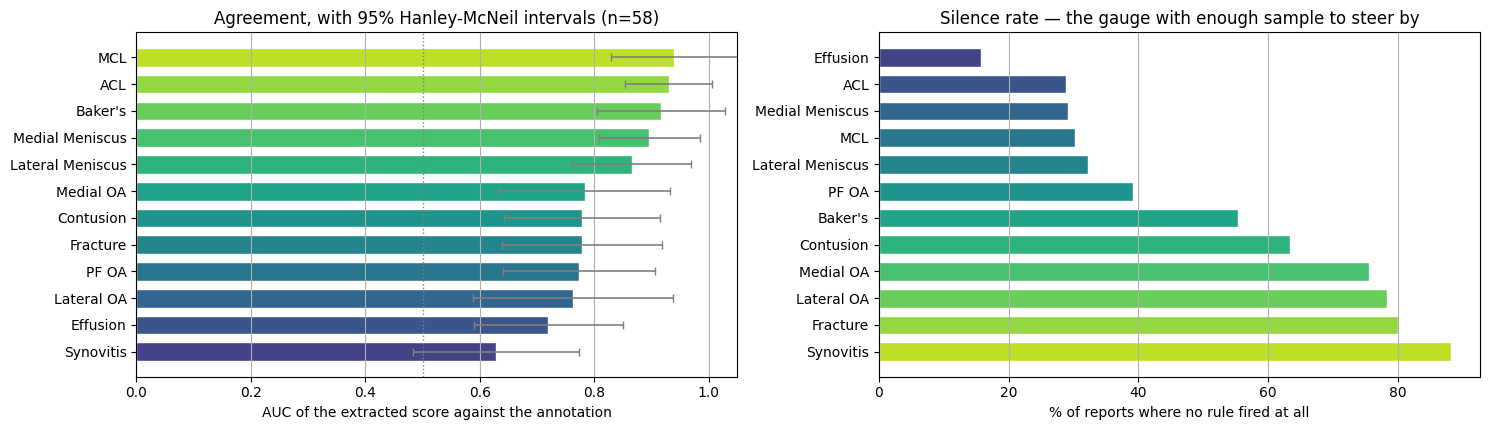

,target,agreement_auc,se,n_pos,n_neg,silence_rate
8,Synovitis,0.628,0.074,27,31,0.882
11,Fracture,0.778,0.071,18,40,0.800
5,Lateral OA,0.763,0.089,11,47,0.783
4,Medial OA,0.783,0.076,15,43,0.755
10,Contusion,0.778,0.070,19,39,0.634
9,Baker's,0.916,0.057,12,46,0.553
6,PF OA,0.773,0.068,21,37,0.391
3,Lateral Meniscus,0.865,0.053,23,35,0.322
1,MCL,0.940,0.056,9,49,0.302
2,Medial Meniscus,0.895,0.045,26,32,0.292


mean agreement AUC 0.814, mean 95% half-width +-0.125
A target whose interval is wider than the gap you are chasing cannot arbitrate a lexicon change. Use the silence column for that.


24

In [13]:
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import roc_auc_score

train_df_diag = pd.read_csv(ROOT / "train.csv")
_t = time.time()
lab_diag = pd.DataFrame([extract(r) for r in train_df_diag["Report"].fillna("")])
log(f"extracted {len(lab_diag)} reports in {time.time() - _t:.1f}s")

silence = pd.Series(
    {t: float(((lab_diag[t + "__npos"] == 0) & (lab_diag[t + "__nneg"] == 0)).mean())
     for t in TARGETS})

gold_diag = train_df_diag.set_index("StudyInstanceUID")[TARGETS]
gold_diag = gold_diag[gold_diag.notna().all(axis=1)]


def hanley_mcneil_se(auc, n_pos, n_neg):
    """Standard error of an AUC estimate; the reason the annotated subset cannot tune."""
    if not np.isfinite(auc) or n_pos < 1 or n_neg < 1:
        return np.nan
    q1 = auc / (2 - auc)
    q2 = 2 * auc ** 2 / (1 + auc)
    var = (auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
           + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg)
    return float(np.sqrt(max(var, 0.0)))


from sklearn.metrics import roc_auc_score

lab_diag.index = train_df_diag["StudyInstanceUID"].values
rows = []
for t in TARGETS:
    y = gold_diag[t].astype(int).values
    p = lab_diag.loc[gold_diag.index, t].values
    auc = roc_auc_score(y, p) if len(set(y)) > 1 else np.nan
    se = hanley_mcneil_se(auc, int(y.sum()), int((1 - y).sum()))
    rows.append({"target": t, "agreement_auc": auc, "se": se,
                 "n_pos": int(y.sum()), "n_neg": int((1 - y).sum()),
                 "silence_rate": silence[t]})
diag = pd.DataFrame(rows)
MIDLINE = "gray"
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
order = diag.sort_values("agreement_auc")
ax = axes[0]
colors = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(order))
)

ax.barh(
    order.target,
    order.agreement_auc,
    color=colors,
    edgecolor="white",
    height=.7
)
ax.errorbar(order.agreement_auc, np.arange(12), xerr=1.96 * order.se, fmt="none",
            ecolor=MIDLINE, elinewidth=1.2, capsize=3)
ax.axvline(.5, color=MIDLINE, ls=":", lw=1)
ax.set_xlim(0, 1.05); ax.set_xlabel("AUC of the extracted score against the annotation")
ax.set_title(f"Agreement, with 95% Hanley-McNeil intervals (n={len(gold_diag)})")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)

ax = axes[1]
order2 = diag.sort_values("silence_rate", ascending=False)
colors2 = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(order2))
)[::-1]

ax.barh(
    order2.target,
    order2.silence_rate * 100,
    color=colors2,
    edgecolor="white",
    height=.7
)
ax.set_xlabel("% of reports where no rule fired at all")
ax.set_title("Silence rate — the gauge with enough sample to steer by")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

display(diag.sort_values("silence_rate", ascending=False).round(3))
print(f"mean agreement AUC {diag.agreement_auc.mean():.3f}, "
      f"mean 95% half-width +-{1.96 * diag.se.mean():.3f}")
print("A target whose interval is wider than the gap you are chasing cannot arbitrate a "
      "lexicon change. Use the silence column for that.")

del train_df_diag, lab_diag, gold_diag
gc.collect()

In [14]:
HDR_TAGS = ["SeriesDescription", "SequenceName", "ScanOptions", "ScanningSequence",
            "RepetitionTime", "EchoTime", "Laterality", "ImageLaterality",
            "ImagePositionPatient", "PixelSpacing", "Rows",
            "Columns", "RescaleSlope", "RescaleIntercept"]


def probe(item):
    split, study, series, path = item
    row = {"split": split, "StudyInstanceUID": study, "SeriesInstanceUID": series,
           "dir": path}
    try:
        files = sorted(e.name for e in os.scandir(path) if e.name.endswith(".dcm"))
        row["files"] = files
        row["n_slices"] = len(files)
        if not files:
            return row
        ds = pydicom.dcmread(os.path.join(path, files[len(files) // 2]),
                             stop_before_pixels=True, force=True)
        for t in HDR_TAGS:
            v = getattr(ds, t, None)
            if v is None:
                row[t] = None
            elif isinstance(v, (list, tuple)) or type(v).__name__ == "MultiValue":
                row[t] = "|".join(str(x) for x in v)
            else:
                row[t] = str(v)
    except Exception as exc:
        row["err"] = str(exc)[:120]
    return row


def walk(split):
    base = ROOT / split
    items = []
    if not base.is_dir():
        return pd.DataFrame()
    for study in os.scandir(base):
        if study.is_dir():
            for series in os.scandir(study.path):
                if series.is_dir():
                    items.append((split, study.name, series.name, series.path))
    with ThreadPoolExecutor(max_workers=HDR_THREADS) as pool:
        rows = list(pool.map(probe, items))
    return pd.DataFrame(rows)


def annotate(df):
    """Recover fat suppression and pulse-sequence weighting from the header."""
    desc = (df["SeriesDescription"].fillna("") + " " + df["SequenceName"].fillna(""))
    desc = desc.str.lower().str.replace(_SEP, " ", regex=True)

    opts = df["ScanOptions"].fillna("").str.upper().str.split("|")
    # GE writes SAT_GEMS for spatial saturation, so ScanOptions must be matched as
    # exact tokens; a substring test on "SAT" fires on non-fat-sat series.
    opts_fs = opts.apply(lambda ts: any(t.strip() in FATSAT_OPTS for t in ts))
    df["fatsat"] = desc.str.contains(_FATSAT_RX) | opts_fs

    tr = pd.to_numeric(df["RepetitionTime"], errors="coerce")
    te = pd.to_numeric(df["EchoTime"], errors="coerce")
    gre = df["ScanningSequence"].fillna("").str.upper().str.contains("GR")
    t1, t2, pdw = desc.str.contains(_T1_RX), desc.str.contains(_T2_RX), desc.str.contains(_PD_RX)

    df["weight"] = np.where(t1 & ~t2 & ~pdw, "T1",
                     np.where(t2 & ~pdw, "T2",
                       np.where(pdw, "PD",
                         np.where(gre, "GRE",
                           np.where(tr < 800, "T1",
                             np.where(te > 60, "T2",
                               np.where(tr >= 800, "PD", "UNK")))))))
    df["fluid"] = np.isin(df["weight"], ["PD", "T2"])
    df["px"] = pd.to_numeric(
        df["PixelSpacing"].fillna("").str.split("|").str[0].replace("", np.nan),
        errors="coerce")
    return df


In [15]:
# --- laterality resolution -----------------------------------------------------------
# The tag is authoritative where it exists. Where it does not, the patient x-coordinate
# can stand in, but only if it agrees with the tag on the studies that have both: a wrong
# flip is worse than no flip, and knee coils often place the joint near isocentre, where
# the sign carries no information at all.

def _tag_side(g):
    v = [str(x).strip().upper() for x in g["Laterality"].dropna()]
    if "ImageLaterality" in g.columns:
        v += [str(x).strip().upper() for x in g["ImageLaterality"].dropna()]
    v = [x[0] for x in v if x and x[0] in ("L", "R")]
    return v[0] if v else None


def _position_side(g):
    xs = []
    for s in g.get("ImagePositionPatient", pd.Series(dtype=object)).dropna():
        try:
            xs.append(float(str(s).split("|")[0]))
        except Exception:
            pass
    if not xs:
        return None
    x = float(np.median(xs))
    if abs(x) < LAT_MIN_OFFSET_MM:
        return None                      # centred in the coil: the sign means nothing
    return "R" if x < 0 else "L"         # LPS: the right knee sits at negative x


def laterality_maps(h):
    """Return (side_by_study, diagnostics). Uses the fallback only if it earns it."""
    tag, pos = {}, {}
    for st, g in h.groupby("StudyInstanceUID"):
        tag[st] = _tag_side(g)
        pos[st] = _position_side(g)

    both = [st for st in tag if tag[st] and pos[st]]
    agree = float(np.mean([tag[st] == pos[st] for st in both])) if both else np.nan
    have_tag = float(np.mean([v is not None for v in tag.values()]))

    if LAT_FALLBACK == "on":
        use = True
    elif LAT_FALLBACK == "off":
        use = False
    else:
        use = bool(both) and np.isfinite(agree) and agree >= LAT_MIN_AGREEMENT

    side = {st: (tag[st] or (pos[st] if use else None)) for st in tag}
    covered = float(np.mean([v is not None for v in side.values()]))
    info = {"tag_coverage": have_tag, "agreement": agree, "n_compared": len(both),
            "fallback_used": use, "final_coverage": covered}
    log(f"laterality: tag on {have_tag:.1%} of studies, x-sign agrees with it on "
        f"{agree:.1%} of {len(both)} comparable studies, fallback "
        f"{'enabled' if use else 'disabled'} -> {covered:.1%} normalised")
    return side, info

In [16]:
def pick_slots(series_df, plane_map):
    """One series per slot per study.

    Ties are broken toward the stack with the most slices: a thicker stack samples the
    joint more densely, and the three-slice sampler below benefits from the margin.
    """
    series_df = series_df.copy()
    series_df["plane"] = series_df["SeriesInstanceUID"].map(plane_map)
    out = {}
    for study, g in series_df.groupby("StudyInstanceUID"):
        chosen = {}
        for name, plane, fluid, fs in SLOTS:
            sel = (g["plane"] == plane) & (g["fatsat"] == fs)
            # fluid=None means "do not condition on weighting" - the public scheme,
            # where the single provided flag stands in for both axes at once.
            if fluid is not None:
                sel &= (g["fluid"] == fluid)
            cand = g[sel]
            if len(cand) == 0 and fluid is False:
                # T1 slots are the scarcest; fall back to any non-fat-sat, non-fluid
                # series in the plane before giving up on the slot entirely.
                cand = g[(g["plane"] == plane) & (~g["fatsat"])]
            if len(cand):
                chosen[name] = cand.sort_values("n_slices", ascending=False).iloc[0]
        out[study] = chosen
    return out


## 4. Sampling at a fixed physical scale

A DICOM slice of $N \times N$ pixels with spacing $s$ mm/pixel covers $N s$ millimetres of
anatomy. Both $N$ and $s$ vary widely across this corpus, so a fixed-pixel resize —
"make everything $224 \times 224$" — hands the encoder images whose physical scale differs
by a factor of about three. A meniscus then occupies a different number of pixels in
different studies for no anatomical reason, and the network has to spend capacity undoing
a nuisance transform it was handed for free.

Crop to a constant physical extent $L$ before resizing. Taking the centre

$$ n \;=\; \Big\lfloor \frac{L}{s} \Big\rceil \quad\text{pixels} $$

and resampling that to $P \times P$ leaves an effective scale of

$$ s_{\text{eff}} \;=\; \frac{L}{P}\ \ \text{mm/pixel} $$

which no longer depends on the acquisition. With $L = 160$ mm — a knee fits comfortably
inside that — and $P = 224$, every study reaches the encoder at $0.71$ mm/pixel.

**Intensity needs the same treatment for the same reason.** MR has no absolute scale: the
same tissue takes a different number on a different sequence, coil or day, so there is no
Hounsfield-unit equivalent to anchor to. Normalising each series to its own 1st and 99th
percentile — over the whole volume, not per slice, so slices keep their relative contrast
— removes an offset that would otherwise track the acquisition site. Percentiles rather
than min and max, because one bright vessel would otherwise compress everything else.

Slices are taken from the central 60% of each stack. The outer slices of a knee series
mostly lie outside the joint, and sampling them spends read bandwidth on soft tissue.


In [17]:
def read_slot(rec, n_slice=None, out_size=None):
    """`n_slice` physically spread slices from one series, at `out_size` pixels.

    Returns float32 [n_slice, out, out] normalised per-series to its 1st-99th
    percentile. Percentiles rather than min/max because MR intensity has no absolute
    scale and a single bright vessel would otherwise compress the whole dynamic range.

    Reading is the expensive half of this pipeline, so the caller reads once at the
    largest configuration it needs and derives the smaller ones from the returned buffer
    rather than re-reading.
    """
    # was `N_SLICE`, which is never defined: a latent NameError on the default path.
    n_slice = CACHE_SLICES if n_slice is None else n_slice
    out_size = IMG if out_size is None else out_size
    files, d, px = rec["files"], rec["dir"], rec["px"]
    n = len(files)
    if n == 0:
        return None
    # Spread the samples over the central 60% of the stack: the outer slices of a knee
    # series are mostly soft tissue outside the joint.
    lo, hi = int(0.20 * (n - 1)), int(0.80 * (n - 1))
    idx = np.unique(np.linspace(lo, hi, n_slice).astype(int)) if hi > lo else np.array([n // 2])
    while len(idx) < n_slice:
        idx = np.append(idx, idx[-1])

    planes = []
    for i in idx[:n_slice]:
        try:
            ds = pydicom.dcmread(os.path.join(d, files[int(i)]), force=True)
            a = ds.pixel_array.astype(np.float32)
            sl = float(getattr(ds, "RescaleSlope", 1) or 1)
            ic = float(getattr(ds, "RescaleIntercept", 0) or 0)
            a = a * sl + ic
        except Exception:
            a = np.zeros((out_size, out_size), dtype=np.float32)
        planes.append(a)

    shp = planes[0].shape
    planes = [p if p.shape == shp else np.zeros(shp, np.float32) for p in planes]
    vol = np.stack(planes)

    # constant physical extent, then resize: PixelSpacing varies 3.4x across the corpus
    if px and np.isfinite(px) and px > 0:
        want = int(round(CROP_MM / px))
        h, w = shp
        if 16 < want < min(h, w):
            cy, cx = h // 2, w // 2
            half = want // 2
            vol = vol[:, max(0, cy - half):cy + half, max(0, cx - half):cx + half]

    lo_v, hi_v = np.percentile(vol, [1, 99])
    vol = np.clip((vol - lo_v) / max(hi_v - lo_v, 1e-6), 0, 1)

    t = torch.from_numpy(np.ascontiguousarray(vol)).unsqueeze(0)
    t = F.interpolate(t, size=(out_size, out_size), mode="bilinear", align_corners=False)
    # uint8, not float32. These buffers queue up between the reader threads and the
    # encoder, and at this size a float32 slot-series is several megabytes. Intensity is
    # already normalised into [0, 1] here, so eight bits cost nothing that a bilinear
    # resize has not already cost, and the queue is a quarter the size.
    return (t.squeeze(0) * 255).round().clamp(0, 255).to(torch.uint8)


## 5. Normalising left and right

Four of the twelve targets — the two menisci and the medial and lateral tibiofemoral
compartments — are medial/lateral pairs. Medial and lateral are defined relative to the
body's midline, so which side of the *image* they fall on depends on which knee was
scanned. Unless that is normalised, those four labels are being asked to learn from an
axis the model cannot observe.

The correction is not the same in every plane, because the mirror acts on a different
image axis:

- **Coronal and axial.** The medial-lateral direction lies in the image plane, so a left
  knee is the horizontal mirror of a right knee. Flipping the last axis maps one onto the
  other.
- **Sagittal.** The medial-lateral direction is the *slice* axis; each individual slice is
  unchanged by mirroring. What differs is the order in which the stack traverses the
  joint, so the slice order is reversed rather than the pixels flipped.

`Laterality` is present in the header for some studies and absent for others. Where it is
absent the volume is left alone: a wrong flip is worse than no flip, and the presence mask
lets the head learn how much to trust each slot.


In [18]:
def normalise_laterality(img, plane, lat):
    """Map every knee onto a left-knee convention.

    Coronal and axial views mirror under a horizontal flip. Sagittal stacks are not
    mirror images of each other - the slice order runs medial-to-lateral in opposite
    directions - so the channel order is reversed instead.
    """
    if lat != "R":
        return img
    if plane in ("Coronal", "Axial"):
        return torch.flip(img, dims=[-1])
    return torch.flip(img, dims=[0])


## 5. Reading once, training many times

The cost of this pipeline is dominated by reading, not by arithmetic. A study holds
several series and each series holds tens of slices, so a study is on the order of a
hundred and fifty files, and the corpus is hundreds of thousands of decodes.

That is affordable once. It is not affordable once per epoch, and fine-tuning needs the
same pixels every epoch. So the slot images are decoded a single time into memory and
held as `uint8`:

$$ \text{bytes} \;=\; N_{\text{study}} \times N_{\text{slot}} \times S \times P^{2} $$

with $S$ slices kept per slot at $P$ pixels. The exponent on $P$ is what makes this a
real constraint rather than a detail — the cache grows with the *square* of resolution
and only linearly with slices, so coverage is the cheap axis and resolution the expensive
one. Eight bits cost nothing that the intensity normalisation of §4 has not already cost.

The cached slices are read as groups of three, each group forming one three-channel
encoder input. Training draws one group per study per step, which doubles as augmentation
along the stack; inference averages the logits over all groups.

Two implementation consequences follow, both about the queue between the reading threads
and the consumer rather than about either alone:

- buffers crossing that queue are `uint8` for the same reason the cache is.
- reads are issued in bounded chunks. Submitting every job at once lets the readers run
  arbitrarily far ahead and the completed results accumulate without limit.

A valid submission file is written before any of this begins and overwritten once real
predictions exist, so the run always leaves a scoreable file behind.


In [19]:
def build_cache(slot_map, plane_map, lat_map, tag):
    """Decode every (study, slot) once into an in-memory uint8 array.

    Fine-tuning revisits the same pixels every epoch. Reading them from the mount each
    time would make the epoch count a function of I/O rather than of learning, so they
    are decoded once and held as bytes: intensity has already been normalised into
    [0, 1], and eight bits cost nothing a bilinear resize has not already cost.

    CACHE_SLICES positions are kept per slot, which the training loop reads as N_GROUP
    groups of GROUP consecutive channels.
    """
    studies = sorted(slot_map)
    sidx = {s: i for i, s in enumerate(studies)}
    cache = np.zeros((len(studies), N_SLOT, CACHE_SLICES, IMG, IMG), np.uint8)
    mask = np.zeros((len(studies), N_SLOT), np.float32)
    log(f"{tag}: cache {cache.shape} = {cache.nbytes / 1024 ** 3:.1f} GB")

    jobs = [(st, k, plane, slot_map[st][name])
            for st in studies
            for k, (name, plane, _, _) in enumerate(SLOTS)
            if name in slot_map[st]]
    log(f"{tag}: decoding {len(jobs)} slot-series")

    CHUNK = 512
    done = 0
    with ThreadPoolExecutor(max_workers=PIX_THREADS) as pool:
        for c0 in range(0, len(jobs), CHUNK):
            block = jobs[c0:c0 + CHUNK]
            for (st, k, plane, _), img in zip(
                    block, pool.map(lambda j: read_slot(j[3], CACHE_SLICES, IMG), block)):
                done += 1
                if img is None:
                    continue
                cache[sidx[st], k] = normalise_laterality(img, plane,
                                                          lat_map.get(st)).numpy()
                mask[sidx[st], k] = 1.0
            if done % 4096 < CHUNK:
                log(f"  {tag} {done}/{len(jobs)}")
            if time.time() - T0 > TIME_BUDGET:
                log(f"  {tag}: time budget reached during decode")
                break
    gc.collect()
    return studies, cache, mask


## Baseline model specification

### Input
- One study is represented by up to six acquisition slots.
- Each slot contains groups of three adjacent/nearby slices.
- Images are cropped at a fixed physical extent and normalized per series.

### Encoder
**DINOv2-Small**, initialized from the attached pretrained weights.

Only the final `UNFREEZE_LAST` transformer blocks and the final normalization are trainable.

### Study-level aggregation
For each slot, the encoder produces a feature vector. A lightweight **diagnosis-specific attention head** then learns which acquisition slots are useful for each of the 12 targets.

### Objective
The main objective is a **confidence-weighted, macro-normalized BCE-with-logits**. A small pairwise ranking term is added because the competition metric is ROC-AUC.

### Stabilization
- EMA model weights
- gradient clipping
- separate learning rates for backbone and head
- OneCycle learning-rate schedule
- fixed seed
- grouped folds
- checkpoint selection using the weaker of derived-label AUC and held-out annotated AUC when available


## 6. Aggregating slots into twelve decisions

A study arrives as up to six slot embeddings $x_s \in \mathbb{R}^{d}$ with a presence
mask $m_s \in \{0,1\}$. Pooling them identically would discard the reason the protocol
has three planes at all: each finding is read on particular sequences, and a mean over
slots dilutes the one that carries the evidence with five that do not.

Project each slot, add a learned slot identity, give every diagnosis $o$ its own query
$q_o \in \mathbb{R}^{H}$, and let it attend over the slots with absent ones masked out of
the softmax:

$$ h_s \;=\; \phi(x_s) + e_s, \qquad
\alpha_{o,s} \;=\; \frac{\exp\!\big(\langle h_s, q_o\rangle / \sqrt{H}\big)\, m_s}
{\sum_{s'} \exp\!\big(\langle h_{s'}, q_o\rangle / \sqrt{H}\big)\, m_{s'}}, $$

$$ c_o \;=\; \sum_s \alpha_{o,s}\, h_s, \qquad
\ell_o \;=\; \langle c_o, w_o \rangle + b_o . $$

The masked softmax renormalises over whatever the study actually contains, so a missing
axial series shifts a diagnosis's attention onto the sequences that are present instead
of feeding it a zero vector.

**The head is deliberately this small.** Richer aggregations are available — attention
over every slice group rather than every slot, or a maximum instead of a mean — and they
are worse. The reason is structural: the label is attached to the *study*, so nothing in
the supervision says which part of a study carries the finding. Extra attention
parameters have no signal to learn that from, and spend their capacity on noise instead.
Where the supervision is coarse, the aggregation should be too.


In [20]:
class SlotHead(nn.Module):
    """Per-diagnosis attention over the slot embeddings of one study.

    Each finding is read on particular sequences - cruciates sagittally, collateral
    ligaments and the meniscal body coronally, patellar cartilage axially - so pooling
    the slots identically would dilute the one that carries the evidence with the rest.

    The aggregation is deliberately this simple. Richer alternatives were measured
    against it and lost: with a study-level label there is no signal telling the model
    which part of a study matters, so extra attention parameters have nothing to learn
    from and spend their capacity fitting noise.
    """

    def __init__(self, dim, n_slot, n_out, hidden=256, p=0.2):
        super().__init__()
        self.proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, hidden), nn.GELU())
        self.slot_emb = nn.Parameter(torch.randn(n_slot, hidden) * 0.02)
        self.query = nn.Parameter(torch.randn(n_out, hidden) * 0.02)
        self.drop = nn.Dropout(p)
        self.out = nn.Linear(hidden, n_out)
        self.hidden = hidden

    def forward(self, x, mask):
        h = self.proj(x) + self.slot_emb
        att = torch.einsum("bsh,oh->bos", h, self.query) / self.hidden ** 0.5
        att = att.masked_fill(mask.unsqueeze(1) < 0.5, -1e4).softmax(-1)
        ctx = self.drop(torch.einsum("bos,bsh->boh", att, h))
        return (ctx * self.out.weight.unsqueeze(0)).sum(-1) + self.out.bias


In [21]:
class Model(nn.Module):
    """Encoder plus head, trained end to end.

    A study arrives as a bag of slot images. The bag is flattened for the encoder and
    folded back before the head, so the encoder never sees the study structure and the
    head never sees pixels.
    """

    def __init__(self, backbone, dim):
        super().__init__()
        self.backbone = backbone
        self.head = SlotHead(dim, N_SLOT, len(TARGETS))
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, imgs, mask):
        B, S = imgs.shape[:2]
        x = imgs.reshape(B * S, *imgs.shape[2:]).float().div_(255.0)
        x = (x - self.mean) / self.std
        out = self.backbone(pixel_values=x).last_hidden_state
        feat = torch.cat([out[:, 0], out[:, 1:].mean(1)], dim=1).reshape(B, S, -1)
        return self.head(feat, mask)


### Why the encoder is trained rather than frozen

A frozen self-supervised encoder is the cheap option and it is where this pipeline
started. It stops paying, and the way it stops is informative: resolution, encoder size,
slice coverage and slot aggregation were each varied while everything else was held
fixed, and none of them moved the score beyond what the validation noise allows.

That pattern is diagnostic. Those four axes change how much the model *looks*, how
closely it looks, and how it summarises what it saw — but none of them changes the
vocabulary it looks with. When every one of them saturates at the same place, the binding
constraint is the representation itself. And there is an obvious reason to expect it
here: the encoder learned its features from natural images, where nothing resembles the
signal a torn meniscus makes on a proton-density sequence.

So the encoder is adapted, with two restraints.

**Only the last blocks move.** The early blocks of a vision transformer are generic edge
and texture filters; the late blocks are where semantics live. There is not enough
supervision here to improve the early ones and quite enough to damage them, so they stay
frozen and the last few are trained.

**The encoder learns far more slowly than the head.** The head is random at
initialisation and has everything to learn; the encoder starts from a good solution and
needs only to be moved off it. A single learning rate would either leave the head
untrained or destroy the encoder in the first few hundred steps, so the two parameter
groups get rates two orders of magnitude apart.

Targets remain the report-derived labels of §2, weighted by the extractor's
per-study confidence, so a study whose report never mentions a finding pulls weakly on
that output rather than asserting a negative.


In [22]:
def build_model():
    """Load the encoder and open the last few blocks for training.

    Only the last UNFREEZE_LAST blocks and the final norm are trainable. The early
    blocks of a self-supervised transformer are generic edge and texture filters; there
    is not enough supervision here to improve them and quite enough to damage them.
    """
    from transformers import AutoModel
    p = find_dinov2("small")
    if p is None:
        raise FileNotFoundError("DINOv2 weights not attached")
    bb = AutoModel.from_pretrained(str(p))
    n_layer = len(bb.encoder.layer)
    for prm in bb.parameters():
        prm.requires_grad = False
    for blk in bb.encoder.layer[max(0, n_layer - UNFREEZE_LAST):]:
        for prm in blk.parameters():
            prm.requires_grad = True
    for prm in bb.layernorm.parameters():
        prm.requires_grad = True
    dim = bb.config.hidden_size * 2
    trainable = sum(p.numel() for p in bb.parameters() if p.requires_grad)
    log(f"backbone: {n_layer} blocks, last {UNFREEZE_LAST} trainable "
        f"({trainable / 1e6:.1f}M params), feature dim {dim}")
    return Model(bb, dim)


In [23]:
def take_group(cache_rows, g):
    """Slice GROUP consecutive channels out of the cached slices."""
    return cache_rows[:, :, g * GROUP:(g + 1) * GROUP]


# `augment` is defined further down, after the reasoning for dropping the flip.


@torch.no_grad()
def predict(model, cache, mask, idx, dev):
    """Average the logits over the groups of each slot.

    Training sees one group at a time, which acts as augmentation along the stack;
    inference averages over all of them, which is the same aggregation the frozen
    pipeline used and the one that measured best.
    """
    model.eval()
    out = []
    for b in range(0, len(idx), EVAL_BATCH):
        sel = idx[b:b + EVAL_BATCH]
        rows = torch.from_numpy(cache[sel]).to(dev)
        m = torch.from_numpy(mask[sel]).to(dev)
        acc = None
        for g in range(N_GROUP):
            with torch.autocast("cuda", enabled=dev.type == "cuda"):
                z = model(take_group(rows, g), m).float()
            acc = z if acc is None else acc + z
        out.append(torch.sigmoid(acc / N_GROUP).cpu().numpy())
    return np.concatenate(out) if out else np.zeros((0, len(TARGETS)), np.float32)


def macro_auc(y, p):
    from sklearn.metrics import roc_auc_score
    return float(np.nanmean([roc_auc_score(y[:, j], p[:, j])
                             if len(set(y[:, j])) > 1 else np.nan
                             for j in range(y.shape[1])]))


In [24]:
def augment(imgs):
    """Anatomically safe augmentation applied consistently to all slices in a study bag.

    Horizontal flipping would undo laterality normalization.
    Vertical flipping exchanges femoral and tibial anatomy.
    Therefore only small affine/intensity perturbations are used.
    """
    B, S, C, H, W = imgs.shape
    x = imgs.float()

    if AUG_AFFINE:
        ang = math.radians((torch.rand(1).item() - 0.5) * 2 * AUG_ROT_DEG)
        sc = 1.0 + (torch.rand(1).item() - 0.5) * 2 * AUG_SCALE
        tx = (torch.rand(1).item() - 0.5) * 2 * AUG_SHIFT
        ty = (torch.rand(1).item() - 0.5) * 2 * AUG_SHIFT
        cos, sin = math.cos(ang) / sc, math.sin(ang) / sc
        theta = torch.tensor([[cos, -sin, tx], [sin, cos, ty]],
                             dtype=torch.float32, device=imgs.device)
        theta = theta.unsqueeze(0).repeat(B * S, 1, 1)
        flat = x.reshape(B * S, C, H, W)
        grid = F.affine_grid(theta, flat.shape, align_corners=False)
        x = F.grid_sample(
            flat, grid, mode="bilinear", padding_mode="zeros",
            align_corners=False
        ).reshape(B, S, C, H, W)

    scale = 1.0 + (torch.rand(1, device=imgs.device) - 0.5) * 2 * AUG_INTENSITY
    x = (x * scale).clamp(0, 255)
    return x.round().to(imgs.dtype)


class Ema:
    """Exponential moving average of model parameters for stable evaluation."""

    def __init__(self, model, decay):
        self.decay = decay
        self.step = 0
        self.model = deepcopy(model).eval()
        for p in self.model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.step += 1
        decay = min(self.decay, (1.0 + self.step) / (10.0 + self.step))
        src = model.state_dict()
        for k, v in self.model.state_dict().items():
            s = src[k]
            if v.dtype.is_floating_point:
                v.mul_(decay).add_(s.detach(), alpha=1.0 - decay)
            else:
                v.copy_(s)

    def target(self, model):
        return self.model if self.decay > 0 else model


def macro_normalized_bce(logits, y, w):
    """Macro-normalized BCE.

    Each label is normalized by its own usable weight before averaging across labels.
    This keeps frequently extracted labels from dominating the objective and better matches
    the macro-AUC evaluation metric.
    """
    loss = F.binary_cross_entropy_with_logits(logits, y, reduction="none") * w
    denom = w.sum(dim=0).clamp_min(1e-6)
    per_label = loss.sum(dim=0) / denom
    usable = (denom > 1e-6).float()
    return (per_label * usable).sum() / usable.sum().clamp_min(1.0)


def rank_loss(logits, y, w):
    """Small pairwise ranking term aligned with ROC-AUC."""
    parts = []
    usable = w > 0
    for j in range(logits.shape[1]):
        pos = logits[(y[:, j] > RANK_POS) & usable[:, j], j]
        neg = logits[(y[:, j] < RANK_NEG) & usable[:, j], j]
        if len(pos) and len(neg):
            parts.append(F.softplus(-(pos[:, None] - neg[None, :])).mean())
    return torch.stack(parts).mean() if parts else logits.new_tensor(0.0)


# Self-tests
_t = torch.randint(0, 255, (2, 3, GROUP, 32, 32), dtype=torch.uint8)
_a = augment(_t)
assert _a.shape == _t.shape and _a.dtype == _t.dtype

_lg = torch.tensor([[2.0], [-2.0]])
_y = torch.tensor([[1.0], [0.0]])
_w = torch.ones(2, 1)
assert rank_loss(_lg, _y, _w) < rank_loss(-_lg, _y, _w)
print("augmentation and ranking-loss self-tests passed")


augmentation and ranking-loss self-tests passed


## 7. Validating without fooling yourself

Two leaks are specific to this setup, and both inflate a validation number without
improving anything.

**Shared reports.** Some reports are byte-identical across studies — a template read for
an unremarkable knee. Every study in such a group receives the same derived target vector.
Split the group across folds and the model is scored on a target whose source it has
already been trained on. Folds are therefore assigned by a hash of the report text, which
keeps every duplicate group whole inside one fold.

**Two references, two meanings.** Out-of-fold performance is reported twice: against the
derived targets, which covers every training study and measures whether the imaging model
learned what the text says; and against the studies with per-condition annotations, which
is far smaller and measures agreement with a reading of the *images*. The second is the
one that resembles the test set. The first is the one with enough positives per label to
distinguish a real difference from noise.

### Choosing which epoch to keep

Having two references makes selection a decision rather than a lookup, and the obvious
rule — take the best epoch on the larger reference — is wrong. The two measure different
things, so an epoch that gains on one while losing on the other has not been shown to be
better; it has been shown to be different. Ranking by

$$ \text{score}(e) \;=\; \min\big(\mathrm{AUC}^{\text{derived}}_e,\ \mathrm{AUC}^{\text{annot}}_e\big) $$

refuses that trade: an epoch is only preferred if its *weaker* evidence is stronger than
every other epoch's weaker evidence. The checkpoint that wins under this rule is the one
restored before predicting, which also makes the training length a measured quantity
rather than a hyperparameter guessed in advance.


In [25]:
def write_benchmark_submission():
    """Create a valid fallback submission before expensive processing starts."""
    t = pd.read_csv(ROOT / "test.csv")
    for c in TARGETS:
        t[c] = 0.5
    t.to_csv("submission.csv", index=False)


def write_submission(rank_sum, n_models, st_te, test_df, path="submission.csv"):
    """Write the current rank-mean ensemble, aligned to the official test index."""
    P = rank_sum / max(n_models, 1)
    sub = pd.DataFrame(P, columns=TARGETS)
    sub.insert(0, "StudyInstanceUID", st_te)
    sub = test_df[["StudyInstanceUID"]].merge(sub, on="StudyInstanceUID", how="left")
    sub[TARGETS] = sub[TARGETS].fillna(0.5).clip(1e-5, 1 - 1e-5)
    sub.to_csv(path, index=False)
    return sub


def validate_submission(path, test_df):
    """Fail loudly if the generated file violates the competition contract."""
    frame = pd.read_csv(path, dtype={"StudyInstanceUID": str})
    expected = ["StudyInstanceUID"] + TARGETS
    assert frame.columns.tolist() == expected, "Submission columns do not match TARGETS"
    assert len(frame) == len(test_df), "Submission row count mismatch"
    assert frame["StudyInstanceUID"].is_unique, "StudyInstanceUID must be unique"
    assert set(frame["StudyInstanceUID"]) == set(test_df["StudyInstanceUID"].astype(str))
    vals = frame[TARGETS].to_numpy(np.float64)
    assert np.isfinite(vals).all(), "Submission contains non-finite values"
    assert ((vals >= 0) & (vals <= 1)).all(), "Predictions must be in [0, 1]"
    return True


def train_one_fold(fold, Ctr, Mtr, Y, W, tr, va, gi_va, gold_y_va, dev):
    """Train one fold and return EMA state, history, and best validation score."""
    # Different but deterministic seeds per fold prevent accidental identical trajectories.
    fold_seed = SEED + 1000 * fold
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)

    model = build_model().to(dev)
    ema = Ema(model, EMA_DECAY)

    opt = torch.optim.AdamW([
        {
            "params": [p for p in model.backbone.parameters() if p.requires_grad],
            "lr": LR_BACKBONE,
        },
        {
            "params": model.head.parameters(),
            "lr": LR_HEAD,
        },
    ], weight_decay=WEIGHT_DECAY)

    steps_per_epoch = max(len(tr) // BATCH_STUDIES, 1)
    total_steps = max(EPOCHS * steps_per_epoch, 1)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=[LR_BACKBONE, LR_HEAD],
        total_steps=total_steps,
        pct_start=0.15,
        anneal_strategy="cos",
    )
    scaler = torch.amp.GradScaler("cuda", enabled=dev.type == "cuda")

    yv = (Y[va] > 0.5).astype(int)
    best_score = -np.inf
    best_state = None
    history = []

    for ep in range(EPOCHS):
        model.train()
        perm = np.random.permutation(tr)
        total_loss, nstep = 0.0, 0

        for b in range(0, len(perm) - BATCH_STUDIES + 1, BATCH_STUDIES):
            sel = perm[b:b + BATCH_STUDIES]
            rows = torch.from_numpy(Ctr[sel]).to(dev)
            g = int(torch.randint(N_GROUP, (1,)).item())
            imgs = augment(take_group(rows, g))
            m = torch.from_numpy(Mtr[sel]).to(dev)
            y = torch.from_numpy(Y[sel]).to(dev)
            w = torch.from_numpy(W[sel]).to(dev)

            with torch.autocast("cuda", enabled=dev.type == "cuda"):
                logits = model(imgs, m)
                loss = macro_normalized_bce(logits, y, w)
                if RANK_LOSS_W > 0:
                    loss = loss + RANK_LOSS_W * rank_loss(logits.float(), y, w)

            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt)
            scaler.update()
            sched.step()
            ema.update(model)

            total_loss += float(loss.detach().cpu())
            nstep += 1

        eval_model = ema.target(model)
        pv = predict(eval_model, Ctr, Mtr, va, dev)
        derived_auc = macro_auc(yv, pv)

        annot_auc = float("nan")
        if gold_y_va is not None and len(gi_va) >= 8:
            annot_auc = macro_auc(
                gold_y_va,
                predict(eval_model, Ctr, Mtr, gi_va, dev)
            )

        # Conservative model selection:
        # if held-out annotation exists, the minimum of the two references is used.
        if np.isfinite(annot_auc):
            selection_score = min(derived_auc, annot_auc)
        else:
            selection_score = derived_auc

        history.append({
            "fold": fold,
            "epoch": ep + 1,
            "loss": total_loss / max(nstep, 1),
            "derived_auc": derived_auc,
            "annotated_auc": annot_auc,
            "selection_score": selection_score,
        })

        log(
            f"fold {fold} | epoch {ep + 1:02d}/{EPOCHS} | "
            f"loss {total_loss / max(nstep, 1):.4f} | "
            f"derived {derived_auc:.4f} | annotated {annot_auc:.4f}"
        )

        if selection_score > best_score:
            best_score = selection_score
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in eval_model.state_dict().items()
            }

        if time.time() - T0 > TIME_BUDGET:
            log("time budget reached inside fold")
            break

    if best_state is None:
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in ema.target(model).state_dict().items()
        }

    del model, opt, sched, scaler, ema
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_state, history, best_score


def build_report_groups(st_tr, train_df):
    """Map identical/near-identical report text to a stable fold group."""
    rep = train_df.set_index("StudyInstanceUID")["Report"].fillna("")
    return np.array([
        int(hashlib.md5(rep.get(s, "").encode("utf-8")).hexdigest()[:8], 16) % N_FOLDS
        for s in st_tr
    ])


def main():
    write_benchmark_submission()

    test_df = pd.read_csv(ROOT / "test.csv", dtype={"StudyInstanceUID": str})
    train_df = pd.read_csv(ROOT / "train.csv", dtype={"StudyInstanceUID": str})
    test_series = pd.read_csv(ROOT / "test_series.csv", dtype={"StudyInstanceUID": str})
    train_series = pd.read_csv(ROOT / "train_series.csv", dtype={"StudyInstanceUID": str})

    log(f"train={train_df.shape} | test={test_df.shape}")

    both = pd.concat([train_series, test_series], ignore_index=True)
    plane_map = dict(zip(both["SeriesInstanceUID"], both["Anatomical_Plane"]))

    log("annotating test series headers")
    hte = annotate(walk("test_series"))
    log("annotating train series headers")
    htr = annotate(walk("train_series"))

    lat_tr, lat_info_tr = laterality_maps(htr)
    lat_te, _ = laterality_maps(hte)
    globals()["LAT_INFO"] = lat_info_tr

    slots_tr = pick_slots(htr, plane_map)
    slots_te = pick_slots(hte, plane_map)

    st_tr, Ctr, Mtr = build_cache(slots_tr, plane_map, lat_tr, "train")
    st_te, Cte, Mte = build_cache(slots_te, plane_map, lat_te, "test")

    # ---------------- labels ------------------------------------------------
    t_lab = time.time()
    lab = pd.DataFrame([extract(r) for r in train_df["Report"].fillna("")])
    lab["StudyInstanceUID"] = train_df["StudyInstanceUID"].values
    lab = lab.set_index("StudyInstanceUID")
    log(f"derived labels built in {time.time() - t_lab:.1f}s")

    gold = train_df.set_index("StudyInstanceUID")[TARGETS]
    gold = gold[gold.notna().all(axis=1)]

    Y = np.zeros((len(st_tr), len(TARGETS)), np.float32)
    W = np.zeros_like(Y)

    for i, st in enumerate(st_tr):
        if st in gold.index:
            Y[i] = gold.loc[st].values
            W[i] = GOLD_WEIGHT
        elif st in lab.index:
            r = lab.loc[st]
            Y[i] = r[TARGETS].values
            conf = r[[t + "__conf" for t in TARGETS]].values.astype(np.float32)
            W[i] = np.clip(
                DERIVED_MIN_WEIGHT + (DERIVED_MAX_WEIGHT - DERIVED_MIN_WEIGHT) * conf,
                DERIVED_MIN_WEIGHT,
                DERIVED_MAX_WEIGHT,
            )

    keep = np.where(W.sum(axis=1) > 0)[0]
    log(f"supervised studies={len(keep)}/{len(st_tr)} | gold={len(gold)}")

    # ---------------- grouped folds -----------------------------------------
    grp = build_report_groups(st_tr, train_df)

    gpos = {s: i for i, s in enumerate(st_tr)}
    gi_all = np.array([gpos[s] for s in gold.index if s in gpos], dtype=int)
    gold_y_all = (
        gold.loc[[st_tr[i] for i in gi_all]].values.astype(int)
        if len(gi_all) else None
    )

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rank_sum = np.zeros((len(st_te), len(TARGETS)), np.float64)

    histories, fold_scores = [], []
    oof_gold = np.full((len(st_tr), len(TARGETS)), np.nan, np.float32)
    n_models = 0

    for fold in range(N_FOLDS):
        va = np.array([i for i in keep if grp[i] == fold], dtype=int)
        tr = np.array([i for i in keep if grp[i] != fold], dtype=int)

        if len(va) == 0 or len(tr) < BATCH_STUDIES:
            log(f"fold {fold}: skipped (train={len(tr)}, valid={len(va)})")
            continue

        gi_va = np.array([i for i in gi_all if grp[i] == fold], dtype=int)
        gold_y_va = (
            gold.loc[[st_tr[i] for i in gi_va]].values.astype(int)
            if len(gi_va) else None
        )

        log(
            f"=== fold {fold} | train={len(tr)} | valid={len(va)} | "
            f"held-out annotated={len(gi_va)} ==="
        )

        t_fold = time.time()
        state, history, best = train_one_fold(
            fold, Ctr, Mtr, Y, W, tr, va, gi_va, gold_y_va, dev
        )
        fold_time = time.time() - t_fold

        histories.extend(history)
        fold_scores.append(best)

        model = build_model().to(dev)
        model.load_state_dict(state)

        if len(gi_va):
            oof_gold[gi_va] = predict(model, Ctr, Mtr, gi_va, dev)

        P = predict(model, Cte, Mte, np.arange(len(st_te)), dev)
        rank_sum += pd.DataFrame(P).rank(method="average", pct=True).values
        n_models += 1

        del model, state, P
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        sub = write_submission(rank_sum, n_models, st_te, test_df)
        validate_submission("submission.csv", test_df)

        log(
            f"fold {fold} finished in {fold_time / 60:.1f} min | "
            f"models={n_models} | submission validated"
        )

        elapsed = time.time() - T0
        if elapsed + 1.15 * fold_time > TIME_BUDGET:
            log("stopping because another full fold would exceed the time budget")
            break

    globals()["HISTORY"] = pd.DataFrame(histories)
    globals()["FOLD_SCORES"] = pd.DataFrame({
        "fold": np.arange(len(fold_scores)),
        "best_selection_score": fold_scores,
    })

    # Final OOF evaluation on held-out annotated studies only.
    if gold_y_all is not None and len(gi_all):
        seen = np.isfinite(oof_gold[gi_all]).all(axis=1)
        if seen.sum() >= 8:
            oof_auc = macro_auc(
                gold_y_all[seen],
                oof_gold[gi_all][seen]
            )
            log(
                f"OOF annotated macro-AUC={oof_auc:.4f} "
                f"on {int(seen.sum())} held-out annotated studies"
            )
            globals()["OOF_GOLD"] = (
                gold_y_all[seen],
                oof_gold[gi_all][seen]
            )

    log(f"completed {n_models} folds; final submission is submission.csv")
    validate_submission("submission.csv", test_df)


if __name__ == "__main__":
    main()


[   20.6s] train=(4407, 14) | test=(3, 1)
[   20.6s] annotating test series headers
[   20.7s] annotating train series headers
[   97.0s] laterality: tag on 50.0% of studies, x-sign agrees with it on 91.4% of 2050 comparable studies, fallback disabled -> 50.0% normalised
[   97.0s] laterality: tag on 33.3% of studies, x-sign agrees with it on 100.0% of 1 comparable studies, fallback enabled -> 100.0% normalised
[  120.3s] train: cache (4407, 6, 9, 224, 224) = 11.1 GB
[  120.6s] train: decoding 23089 slot-series
[  288.6s]   train 4096/23089
[  459.3s]   train 8192/23089
[  630.1s]   train 12288/23089
[  802.8s]   train 16384/23089
[  973.6s]   train 20480/23089
[ 1083.8s] test: cache (3, 6, 9, 224, 224) = 0.0 GB
[ 1083.8s] test: decoding 14 slot-series
[ 1084.5s]   test 14/14
[ 1102.3s] derived labels built in 17.5s
[ 1105.0s] supervised studies=4407/4407 | gold=58
[ 1105.1s] === fold 0 | train=3526 | valid=881 | held-out annotated=11 ===


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[ 1123.4s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[ 1217.0s] fold 0 | epoch 01/12 | loss 0.6989 | derived 0.6746 | annotated 0.6746
[ 1314.7s] fold 0 | epoch 02/12 | loss 0.6857 | derived 0.7021 | annotated 0.6818
[ 1411.2s] fold 0 | epoch 03/12 | loss 0.6771 | derived 0.7181 | annotated 0.7169
[ 1507.3s] fold 0 | epoch 04/12 | loss 0.6674 | derived 0.7265 | annotated 0.7011
[ 1603.3s] fold 0 | epoch 05/12 | loss 0.6607 | derived 0.7381 | annotated 0.6676
[ 1699.5s] fold 0 | epoch 06/12 | loss 0.6542 | derived 0.7473 | annotated 0.6606
[ 1795.7s] fold 0 | epoch 07/12 | loss 0.6458 | derived 0.7542 | annotated 0.6829
[ 1891.9s] fold 0 | epoch 08/12 | loss 0.6386 | derived 0.7582 | annotated 0.7120
[ 1988.1s] fold 0 | epoch 09/12 | loss 0.6322 | derived 0.7602 | annotated 0.6972
[ 2084.3s] fold 0 | epoch 10/12 | loss 0.6273 | derived 0.7618 | annotated 0.7002
[ 2180.5s] fold 0 | epoch 11/12 | loss 0.6234 | derived 0.7617 | annotated 0.7117
[ 2276.7s] fold 0

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[ 2277.5s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[ 2278.4s] fold 0 finished in 19.5 min | models=1 | submission validated
[ 2278.4s] === fold 1 | train=3573 | valid=834 | held-out annotated=12 ===


...

[ 5748.1s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[ 5749.0s] fold 3 finished in 19.3 min | models=4 | submission validated
[ 5749.0s] === fold 4 | train=3537 | valid=870 | held-out annotated=20 ===


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[ 5749.3s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[ 5845.9s] fold 4 | epoch 01/12 | loss 0.6994 | derived 0.6905 | annotated 0.7241
[ 5942.4s] fold 4 | epoch 02/12 | loss 0.6865 | derived 0.7164 | annotated 0.7573
[ 6038.9s] fold 4 | epoch 03/12 | loss 0.6763 | derived 0.7405 | annotated 0.7581
[ 6135.4s] fold 4 | epoch 04/12 | loss 0.6696 | derived 0.7503 | annotated 0.7736
[ 6231.9s] fold 4 | epoch 05/12 | loss 0.6624 | derived 0.7618 | annotated 0.7881
[ 6328.3s] fold 4 | epoch 06/12 | loss 0.6547 | derived 0.7705 | annotated 0.7811
[ 6424.9s] fold 4 | epoch 07/12 | loss 0.6487 | derived 0.7779 | annotated 0.7992
[ 6521.4s] fold 4 | epoch 08/12 | loss 0.6422 | derived 0.7807 | annotated 0.8075
[ 6618.0s] fold 4 | epoch 09/12 | loss 0.6340 | derived 0.7823 | annotated 0.8102
[ 6714.4s] fold 4 | epoch 10/12 | loss 0.6306 | derived 0.7826 | annotated 0.8045
[ 6811.0s] fold 4 | epoch 11/12 | loss 0.6260 | derived 0.7833 | annotated 0.8122
[ 6907.4s] fold 4

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[ 6908.2s] backbone: 12 blocks, last 6 trainable (10.7M params), feature dim 768
[ 6909.3s] fold 4 finished in 19.3 min | models=5 | submission validated
[ 6909.3s] OOF annotated macro-AUC=0.7616 on 58 held-out annotated studies
[ 6909.3s] completed 5 folds; final submission is submission.csv


,fold,epoch,loss,derived_auc,annotated_auc,selection_score
50,4,3,0.676336,0.740522,0.758145,0.740522
51,4,4,0.669580,0.750349,0.773599,0.750349
52,4,5,0.662377,0.761752,0.788054,0.761752
53,4,6,0.654717,0.770487,0.781139,0.770487
54,4,7,0.648710,0.777910,0.799153,0.777910
55,4,8,0.642195,0.780710,0.807527,0.780710
56,4,9,0.633966,0.782315,0.810170,0.782315
57,4,10,0.630559,0.782605,0.804547,0.782605
58,4,11,0.625961,0.783309,0.812169,0.783309
59,4,12,0.625209,0.783208,0.814446,0.783208


,best_selection_score
fold,
0,0.716931
1,0.743210
2,0.789140
3,0.769432
4,0.783309


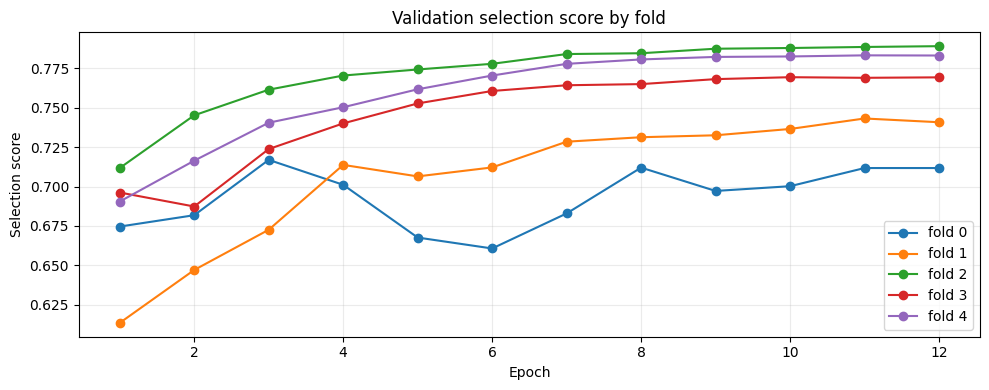

Laterality diagnostics:


,tag_coverage,agreement,n_compared,fallback_used,final_coverage
0,0.499887,0.914146,2050,False,0.499887


In [26]:
# --------------------------- run diagnostics ------------------------------------------
if "HISTORY" in globals() and len(HISTORY):
    h = HISTORY.copy()
    display(h.tail(10))

    if "selection_score" in h.columns:
        best_by_fold = h.groupby("fold")["selection_score"].max()
        display(best_by_fold.to_frame("best_selection_score"))

    fig, ax = plt.subplots(figsize=(10, 4))
    for fold in sorted(h["fold"].unique()):
        q = h[h["fold"] == fold]
        ax.plot(q["epoch"], q["selection_score"], marker="o", label=f"fold {fold}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Selection score")
    ax.set_title("Validation selection score by fold")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

if "SLOT_COVERAGE" in globals():
    print("Slot coverage:")
    display(SLOT_COVERAGE.sort_values(ascending=False).to_frame("coverage"))

if "LAT_INFO" in globals():
    print("Laterality diagnostics:")
    display(pd.DataFrame([LAT_INFO]))


## Where the next points are

**The silence chart is the work queue.** A target that is silent on a large share of reports
is one whose training signal is mostly the 0.28 floor, and no amount of encoder capacity
recovers a label that was never extracted. Read twenty reports in the language with the
highest silence for the worst target and the missing vocabulary is usually three or four
stems.

**The annotator's threshold is a target-specific offset, not a global one.** Section 2 grades
mentions because the reporting radiologist and the annotator disagree about what counts.
That disagreement is not the same size for every finding — a trace effusion is routinely
reported and rarely annotated, whereas a fracture is either there or not. The per-target
agreement chart shows where the mismatch is worst, and the severity cutoffs in `_severity`
are the knob for it.

**Resolution is the untested axis.** The physical-scale argument in §4 fixes mm per pixel at
`CROP_MM / IMG`. Both terms are free: a tighter crop at the same grid, or the same crop on a
finer grid, each buy resolution where the meniscus is. The cache is quadratic in `IMG` and
linear in slices, so the trade is against slice coverage, and the budget planner already
makes that trade explicit.

**A second encoder would ensemble well.** The folds currently differ only by their data
split. Swapping the backbone for one fold — a larger DINOv2, or a supervised ImageNet
transformer — decorrelates the errors far more than a different split does, and the rank
mean already in place is the right way to combine them.

**What not to spend time on.** Calibration, thresholds, and class rebalancing: §1 rules all
three out. And no horizontal or vertical flip anywhere — the first undoes the laterality
normalisation, the second exchanges the femur with the tibia.

# Experimental protocol for improving the baseline

## Phase 1 — establish the reference

Run this notebook unchanged and record:

| Item | Record |
|---|---|
| Seed | 2026 |
| Number of folds | 5 |
| Backbone | DINOv2-Small |
| Trainable blocks | Last 6 |
| Input resolution | 224 |
| Physical crop | 160 mm |
| Slice group | 3 |
| Loss | Macro-normalized weighted BCE + 0.05 ranking loss |
| Model selection | `min(derived AUC, held-out annotated AUC)` |
| Ensemble | Rank mean across completed folds |

The most important number is the **OOF annotated macro-AUC**, not a single public leaderboard score.

## Phase 2 — one-factor-at-a-time ablations

Change exactly one component per experiment:

1. `GROUP`: 3 → 4 or 5
2. `IMG`: 224 → 280
3. `CROP_MM`: 160 → 140
4. `UNFREEZE_LAST`: 4 / 6 / 8
5. `EMA_DECAY`: 0 / 0.995
6. ranking-loss weight: 0 / 0.05 / 0.10
7. slot scheme: `recovered` vs `public`
8. backbone: DINOv2-Small → larger encoder
9. aggregation: diagnosis-specific attention → mean/max baseline

Keep the same folds and seed whenever possible.

## Phase 3 — error analysis

For each target, report:

- OOF AUC
- positive prevalence
- number of usable weak labels
- number of held-out gold labels
- sensitivity/specificity at a diagnostic threshold **only for analysis**
- false-positive examples
- false-negative examples

Do not tune the competition pipeline using a threshold because the competition metric is ROC-AUC.

## Phase 4 — add model diversity

Only after the single-model baseline is stable, add a second encoder such as DINOv3, RadImageNet, or a supervised medical-imaging backbone.

Combine predictions using **OOF-selected weights** or rank averaging. Do not copy fixed public-leaderboard weights into the baseline.

## Phase 5 — reproducibility checklist

A run is considered reproducible only if:

- the same preprocessing produces the same slot coverage,
- fold membership is unchanged,
- the same seed gives comparable training curves,
- every fold produces a valid checkpoint,
- OOF predictions are saved,
- the final submission passes schema validation,
- and the experiment configuration is recorded.

This gives a defensible research baseline for the RSNA Knee Abnormality Detection project and a clean starting point for later attention, cross-plane, cross-sequence, multimodal-fusion, ablation, and explainability experiments.
